In [1]:
import pandas as pd
import numpy as np

In [2]:
clinical = pd.read_csv(
    "TCGA_BRCA_Clinica_information_with_vital_status_and_days_to_death.txt",
    sep="\t",
    index_col=0
)

In [3]:
mol_status = pd.read_csv(
    "TCGA_BRCA_subset_of_clinical_supplement_information_all_patients.csv",
    sep=",",
    index_col=0
)

In [4]:
death_data = pd.read_csv(
    "TCGA_BRCA_vital_status_info.csv",
    sep=","
)

In [5]:
death_data = death_data[["vital_status_gdc", "submitter_id"]]

In [6]:
mol_status["OS_time"] = np.where(
    mol_status["vital_status"] == "Dead",
    mol_status["death_days_to"],
    mol_status["last_contact_days_to"]
)

mol_status["OS_event"] = np.where(
    mol_status["vital_status"] == "Dead",
    1,
    0
)

In [7]:
mol_status_use = mol_status[["er_status_by_ihc", "pr_status_by_ihc", "her2_status_by_ihc","ajcc_pathologic_tumor_stage"]]

In [8]:
mol_status_use = mol_status_use[mol_status_use["er_status_by_ihc"].isin(["Positive", "Negative"])]

In [9]:
mol_status_use["er_status_by_ihc"].value_counts()

er_status_by_ihc
Positive    808
Negative    238
Name: count, dtype: int64

In [69]:
mol_status_use

,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage
bcr_patient_barcode,,,,
TCGA-3C-AAAU,Positive,Positive,Negative,Stage X
TCGA-3C-AALI,Positive,Positive,Positive,Stage IIB
TCGA-3C-AALJ,Positive,Positive,Indeterminate,Stage IIB
TCGA-3C-AALK,Positive,Positive,Positive,Stage IA
TCGA-4H-AAAK,Positive,Positive,Equivocal,Stage IIIA
...,...,...,...,...
TCGA-WT-AB44,Positive,Positive,Negative,Stage IA
TCGA-XX-A899,Positive,Positive,Negative,Stage IIIA
TCGA-XX-A89A,Positive,Positive,Negative,Stage IIB


In [12]:
exp_data = pd.read_csv(
    "TCGA_BRCA_VSD_transformed_expression_matrix_above_75th_quantile_variance_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [17]:
mut_status_data = pd.read_csv(
    "TCGA_BRCA_mutation_status_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [14]:
mut_count_data = pd.read_csv(
    "TCGA_BRCA_mutation_count_overlapping_patients.csv",
    sep=",",
    index_col=0
)

In [28]:
cnv_data = pd.read_csv(
    "TCGA_BRCA_CNV_data_for_genes_used_from_RNA_data.csv",
    sep=",",
    index_col=0
)

In [34]:
dna_meth_data = pd.read_csv(
    "TCGA_BRCA_CpG_from_Human_Meth27K.csv",
    sep=",",
    index_col=0
)

In [16]:
exp_data

,TCGA-A7-A0DC,TCGA-BH-A0B6,TCGA-A8-A084,TCGA-A8-A06U,TCGA-D8-A146,TCGA-A8-A09K,TCGA-C8-A1HI,TCGA-B6-A1KC,TCGA-PL-A8LV,TCGA-E2-A1L7,...,TCGA-A8-A09N,TCGA-A8-A094,TCGA-AR-A24P,TCGA-A8-A0A1,TCGA-BH-A1EX,TCGA-BH-A204,TCGA-BH-A1FJ,TCGA-A8-A081,TCGA-A8-A09G,TCGA-A1-A0SF
ENSG00000000003.15,12.281793,10.944902,9.436177,11.428717,11.624694,11.068687,11.588461,10.916206,11.584126,11.174063,...,10.092051,12.262237,11.472167,11.892701,12.393158,9.620586,11.159879,12.997104,11.071712,13.327855
ENSG00000000971.16,10.103367,11.688588,11.481397,10.836507,11.747974,10.698056,11.803201,11.140024,11.135222,11.538419,...,11.291298,12.723185,11.460371,11.571588,12.413721,11.678929,10.262778,11.069776,11.330711,11.676899
ENSG00000001561.7,11.879582,11.552540,9.831606,11.316343,11.182561,10.264639,11.174784,12.359201,10.257153,10.474596,...,11.381828,12.084238,10.541624,10.577176,10.456138,12.414678,11.957356,10.895237,12.022969,8.824947
ENSG00000001617.12,12.015984,12.987438,14.010859,11.986202,12.512389,13.907958,12.243907,14.480071,11.220464,13.107525,...,13.818017,11.280810,13.364774,12.009907,11.622308,13.321589,12.382929,12.823587,12.667245,12.623880
ENSG00000002586.20,11.009406,13.592980,13.441111,12.818524,13.657548,11.356254,13.412123,11.489102,13.416344,13.092871,...,12.316866,14.527678,13.408144,13.059283,13.341463,11.677567,13.064604,12.517089,13.388379,13.081448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287826.1,8.124775,8.043853,6.807847,8.905604,7.891631,10.030253,11.435953,10.362130,7.018643,7.836831,...,8.848280,7.246223,9.490375,7.574908,7.046116,8.824913,8.455944,8.209589,7.082352,7.462584
ENSG00000287853.1,7.101321,7.439859,7.250942,7.517196,7.206396,7.302212,7.106541,7.159825,7.201341,7.600503,...,7.292365,7.246223,7.139886,7.124067,7.561098,7.021948,6.924020,7.160472,6.981616,7.462584
ENSG00000287900.1,9.934951,6.953940,8.151339,7.050948,7.950259,11.633505,7.942764,9.292597,7.065904,10.651451,...,6.807847,8.512462,7.425676,8.962454,8.685331,7.503703,6.807847,7.794590,6.981616,7.095579
ENSG00000287914.1,10.906179,8.028398,9.276883,8.932383,9.883833,11.132134,7.834846,8.975082,6.956969,8.830914,...,9.293643,7.450283,8.958968,10.472060,7.416151,9.589016,9.554228,9.374897,7.154758,9.234335


In [18]:
mut_status_data

,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT0,TCGA-5L-AAT1,TCGA-5T-A9QA,TCGA-A1-A0SB,TCGA-A1-A0SD,...,TCGA-UL-AAZ6,TCGA-UU-A93S,TCGA-V7-A7HQ,TCGA-W8-A86G,TCGA-WT-AB41,TCGA-WT-AB44,TCGA-XX-A899,TCGA-XX-A89A,TCGA-Z7-A8R5,TCGA-Z7-A8R6
CEP350_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_status,0,1,1,0,0,1,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
TLN1_status,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_status,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
NIPBL_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
MMP1_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZNF77_status,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PIP_status,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [19]:
mut_count_data

,TCGA-3C-AAAU,TCGA-3C-AALI,TCGA-3C-AALJ,TCGA-3C-AALK,TCGA-4H-AAAK,TCGA-5L-AAT0,TCGA-5L-AAT1,TCGA-5T-A9QA,TCGA-A1-A0SB,TCGA-A1-A0SD,...,TCGA-UL-AAZ6,TCGA-UU-A93S,TCGA-V7-A7HQ,TCGA-W8-A86G,TCGA-WT-AB41,TCGA-WT-AB44,TCGA-XX-A899,TCGA-XX-A89A,TCGA-Z7-A8R5,TCGA-Z7-A8R6
CEP350_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTN_count,0,1,1,0,0,1,2,0,0,0,...,0,1,0,0,0,0,0,0,0,0
TLN1_count,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
PTEN_count,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
NIPBL_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HR_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
MMP1_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ZNF77_count,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
PIP_count,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
cnv_data

,ENSG00000225972,ENSG00000225630,ENSG00000237973,ENSG00000248527,ENSG00000198744,ENSG00000223764,ENSG00000187634,ENSG00000188290,ENSG00000187608,ENSG00000188157,...,ENSG00000130822,ENSG00000130821,ENSG00000198753,ENSG00000184343,ENSG00000067840,ENSG00000198910,ENSG00000089820,ENSG00000196924,ENSG00000196976,ENSG00000155961
TCGA-A8-A09E,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,-0.5085,...,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038,-0.0038
TCGA-A7-A0DC,0.0006,0.0006,0.0006,0.0006,0.0006,-0.2208,-0.2208,-0.2208,-0.2208,-0.2208,...,0.0231,0.0231,0.0231,0.0231,0.0231,0.0231,0.0231,0.0231,0.0231,0.0231
TCGA-A7-A0CD,0.4295,0.4295,0.4295,0.4295,0.4295,-0.2005,-0.2005,-0.2005,-0.2005,-0.2005,...,-0.0309,-0.0309,-0.0309,-0.0309,-0.0309,-0.0309,-0.0309,-0.0309,-0.0309,0.0593
TCGA-A8-A07E,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,-0.0081,...,0.0066,0.0066,0.0066,0.0066,0.0066,0.0066,0.0066,0.0066,0.0066,0.0066
TCGA-AR-A0U0,0.0149,0.0149,0.0149,0.0149,0.0149,0.0149,0.0149,0.0149,0.0149,0.0149,...,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400,-0.0400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-AO-A0J4,0.7357,0.7357,0.7357,0.7357,0.7357,0.7357,0.7357,0.7357,0.7357,0.7357,...,0.2274,0.2274,0.2274,0.2274,0.2274,0.2274,0.2274,0.2274,0.2274,0.2274
TCGA-GM-A2DD,-0.1727,-0.1727,-0.1727,-0.1727,-0.1727,0.3568,0.3568,0.3568,0.3568,0.3568,...,0.1291,0.1291,0.1291,0.1291,0.1291,0.1291,0.1291,0.2810,0.2810,-0.0485
TCGA-EW-A1PB,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,-0.0858,...,0.2915,0.2915,0.2915,0.2915,0.2915,0.2915,0.2915,0.2915,0.2915,0.2915
TCGA-C8-A26V,0.1066,0.1066,0.1066,0.1066,0.1066,0.1066,0.1066,0.1066,0.1066,0.1066,...,0.4296,0.4296,0.4296,0.4296,0.4296,0.4296,0.4296,0.4296,0.4296,0.4296


In [35]:
dna_meth_data

,TCGA-A7-A0DC,TCGA-A7-A0CD,TCGA-AO-A0J5,TCGA-A8-A07G,TCGA-C8-A134,TCGA-AN-A0FD,TCGA-E2-A15R,TCGA-AN-A0FZ,TCGA-A8-A0A2,TCGA-AN-A0FF,...,TCGA-E2-A15D,TCGA-A8-A09V,TCGA-A8-A07B,TCGA-E2-A14P,TCGA-AO-A0J4,TCGA-AN-A04A,TCGA-A8-A07C,TCGA-BH-A18R,TCGA-A2-A04T,TCGA-D8-A140
cg04672450,0.015533,0.017421,0.013536,0.019306,0.017192,0.015958,0.008017,0.016241,0.021425,0.026621,...,0.009818,0.018534,0.012889,0.017397,0.020303,0.018941,0.016533,0.011160,0.025547,0.011684
cg04485075,0.023270,0.017592,0.025878,0.023633,0.044438,0.024846,0.017716,0.023455,0.023842,0.019965,...,0.024808,0.023085,0.026167,0.018740,0.015760,0.025638,0.018702,0.020909,0.024403,0.018725
cg21832150,0.019075,0.019580,0.021299,0.020081,0.034821,0.025103,0.013106,0.018704,0.024717,0.016728,...,0.017047,0.025801,0.020542,0.024072,0.022224,0.022112,0.023593,0.022593,0.020778,0.012225
cg02397514,0.012986,0.009335,0.016176,0.016701,0.028162,0.014785,0.009173,0.012499,0.014325,0.013618,...,0.008669,0.010374,0.011955,0.018846,0.021644,0.080319,0.014843,0.010466,0.017233,0.408906
cg08122545,0.025610,0.020741,0.024506,0.022830,0.070846,0.026185,0.014642,0.020046,0.017549,0.021533,...,0.026328,0.023419,0.024716,0.036356,0.014085,0.025326,0.016733,0.024159,0.024184,0.342340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cg00618396,0.402602,0.442455,0.458245,0.555331,0.017222,0.370480,0.141278,0.472521,0.371077,0.551705,...,0.488422,0.560883,0.571088,0.344421,0.436922,0.477924,0.322106,0.401144,0.507217,0.429736
cg00547789,0.206673,0.225487,0.251408,0.393222,0.308057,0.042401,0.330093,0.036177,0.697891,0.249937,...,0.107136,0.211858,0.797088,0.127342,0.123147,0.320245,0.070963,0.105821,0.311292,0.603450
cg02298008,0.548464,0.239208,0.244374,0.356224,0.219893,0.157956,0.078072,0.100958,0.713440,0.339377,...,0.211343,0.162232,0.797447,0.196622,0.209082,0.198477,0.135433,0.286326,0.457548,0.521279
cg06659128,0.243269,0.241267,0.275455,0.367202,0.226412,0.274669,0.059855,0.170349,0.149199,0.213868,...,0.129125,0.144067,0.199832,0.187287,0.326592,0.200127,0.248358,0.331954,0.391968,0.125870


In [40]:
cnv_data = cnv_data.T

In [41]:
cnv_data

,TCGA-A8-A09E,TCGA-A7-A0DC,TCGA-A7-A0CD,TCGA-A8-A07E,TCGA-AR-A0U0,TCGA-A2-A0D4,TCGA-E9-A247,TCGA-BH-A0C0,TCGA-D8-A1XU,TCGA-E9-A1R4,...,TCGA-WT-AB41,TCGA-A8-A07C,TCGA-BH-A0RX,TCGA-E2-A1AZ,TCGA-AC-A2FM,TCGA-AO-A0J4,TCGA-GM-A2DD,TCGA-EW-A1PB,TCGA-C8-A26V,TCGA-B6-A1KF
ENSG00000225972,-0.5085,0.0006,0.4295,-0.0081,0.0149,-0.1940,0.0542,0.3446,-0.2439,-0.1556,...,-0.3860,0.0695,-0.2331,0.1435,-0.5731,0.7357,-0.1727,-0.0858,0.1066,-0.4106
ENSG00000225630,-0.5085,0.0006,0.4295,-0.0081,0.0149,-0.1940,0.0542,0.3446,-0.2439,-0.1556,...,-0.3860,0.0695,-0.2331,0.1435,-0.5731,0.7357,-0.1727,-0.0858,0.1066,-0.4106
ENSG00000237973,-0.5085,0.0006,0.4295,-0.0081,0.0149,-0.1940,0.0542,0.3446,-0.2439,-0.1556,...,-0.3860,0.0695,-0.2331,0.1435,-0.5731,0.7357,-0.1727,-0.0858,0.1066,-0.4106
ENSG00000248527,-0.5085,0.0006,0.4295,-0.0081,0.0149,-0.1940,0.0542,0.3446,-0.2439,-0.1556,...,-0.3860,0.0695,-0.2331,0.1435,-0.5731,0.7357,-0.1727,-0.0858,0.1066,-0.4106
ENSG00000198744,-0.5085,0.0006,0.4295,-0.0081,0.0149,-0.1940,0.0542,0.3446,-0.2439,-0.1556,...,-0.3860,0.0695,-0.2331,0.1435,-0.5731,0.7357,-0.1727,-0.0858,0.1066,-0.4106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000198910,-0.0038,0.0231,-0.0309,0.0066,-0.0400,0.1206,-0.4516,0.4614,0.0176,0.7747,...,-0.0034,0.2839,0.0096,0.0099,0.0039,0.2274,0.1291,0.2915,0.4296,-0.1372
ENSG00000089820,-0.0038,0.0231,-0.0309,0.0066,-0.0400,0.1206,-0.4516,0.4614,0.0176,0.7747,...,-0.0034,0.2839,0.0096,0.0099,0.0039,0.2274,0.1291,0.2915,0.4296,-0.1372
ENSG00000196924,-0.0038,0.0231,-0.0309,0.0066,-0.0400,0.0325,-0.4516,0.4614,0.0176,0.5059,...,-0.0034,0.2839,0.0096,0.0099,0.0039,0.2274,0.2810,0.2915,0.4296,-0.1372
ENSG00000196976,-0.0038,0.0231,-0.0309,0.0066,-0.0400,0.0325,-0.4516,0.4614,0.0176,0.5059,...,-0.0034,0.2839,0.0096,0.0099,0.0039,0.2274,0.2810,0.2915,0.4296,-0.1372


In [42]:
exp_samples = set(exp_data.columns)
mut_samples = set(mut_status_data.columns)
cnv_samples = set(cnv_data.columns)
meth_samples = set(dna_meth_data.columns)


In [44]:
meth_samples

{'TCGA-A1-A0SD',
 'TCGA-A2-A04N',
 'TCGA-A2-A04P',
 'TCGA-A2-A04Q',
 'TCGA-A2-A04T',
 'TCGA-A2-A04U',
 'TCGA-A2-A04V',
 'TCGA-A2-A04W',
 'TCGA-A2-A04X',
 'TCGA-A2-A04Y',
 'TCGA-A2-A0CL',
 'TCGA-A2-A0CM',
 'TCGA-A2-A0CP',
 'TCGA-A2-A0CQ',
 'TCGA-A2-A0CS',
 'TCGA-A2-A0CU',
 'TCGA-A2-A0CV',
 'TCGA-A2-A0CW',
 'TCGA-A2-A0CX',
 'TCGA-A2-A0CY',
 'TCGA-A2-A0CZ',
 'TCGA-A2-A0D0',
 'TCGA-A2-A0D1',
 'TCGA-A2-A0D2',
 'TCGA-A2-A0D3',
 'TCGA-A2-A0D4',
 'TCGA-A2-A0EM',
 'TCGA-A2-A0EO',
 'TCGA-A2-A0EQ',
 'TCGA-A2-A0ER',
 'TCGA-A2-A0ES',
 'TCGA-A2-A0ET',
 'TCGA-A2-A0EV',
 'TCGA-A2-A0EW',
 'TCGA-A2-A0EX',
 'TCGA-A2-A0EY',
 'TCGA-A2-A0T3',
 'TCGA-A7-A0CD',
 'TCGA-A7-A0CE',
 'TCGA-A7-A0CG',
 'TCGA-A7-A0CH',
 'TCGA-A7-A0CJ',
 'TCGA-A7-A0DA',
 'TCGA-A7-A0DB',
 'TCGA-A7-A0DC',
 'TCGA-A8-A06N',
 'TCGA-A8-A06O',
 'TCGA-A8-A06P',
 'TCGA-A8-A06Q',
 'TCGA-A8-A06R',
 'TCGA-A8-A06T',
 'TCGA-A8-A06U',
 'TCGA-A8-A06X',
 'TCGA-A8-A06Y',
 'TCGA-A8-A06Z',
 'TCGA-A8-A076',
 'TCGA-A8-A079',
 'TCGA-A8-A07B',
 'TCGA-A8-A07C

In [76]:
common_samples = sorted(
    set(exp_data.columns)
    & set(mut_status_data.columns)
    & set(cnv_data.columns)
    & set(dna_meth_data.columns)
)

print(len(common_samples))

292


In [65]:
print(
    set(common_samples).issubset(exp_data.columns),
    set(common_samples).issubset(mut_status_data.index),
    set(common_samples).issubset(cnv_data.index),
    set(common_samples).issubset(dna_meth_data.columns)
)

True True True True


In [67]:
print("Expression vs mutation:",
      set(exp_common.columns) == set(mut_common.index))

print("Expression vs CNV:",
      set(exp_common.columns) == set(cnv_common.index))

print("Expression vs methylation:",
      set(exp_common.columns) == set(meth_common.columns))

Expression vs mutation: True
Expression vs CNV: True
Expression vs methylation: True


In [68]:
sample_ids_4omics = pd.Index(common_samples, name="sample_id")

sample_ids_4omics.to_series().to_csv(
    "TCGA_BRCA_4omics_common_samples.csv",
    index=False,
    header=True
)

In [74]:
mol_status_use.index

Index(['TCGA-3C-AAAU', 'TCGA-3C-AALI', 'TCGA-3C-AALJ', 'TCGA-3C-AALK',
       'TCGA-4H-AAAK', 'TCGA-5L-AAT0', 'TCGA-5L-AAT1', 'TCGA-5T-A9QA',
       'TCGA-A1-A0SB', 'TCGA-A1-A0SD',
       ...
       'TCGA-UL-AAZ6', 'TCGA-UU-A93S', 'TCGA-V7-A7HQ', 'TCGA-W8-A86G',
       'TCGA-WT-AB41', 'TCGA-WT-AB44', 'TCGA-XX-A899', 'TCGA-XX-A89A',
       'TCGA-Z7-A8R5', 'TCGA-Z7-A8R6'],
      dtype='str', name='bcr_patient_barcode', length=1046)

In [77]:
common_samples

['TCGA-A1-A0SD',
 'TCGA-A2-A04N',
 'TCGA-A2-A04P',
 'TCGA-A2-A04Q',
 'TCGA-A2-A04T',
 'TCGA-A2-A04U',
 'TCGA-A2-A04V',
 'TCGA-A2-A04W',
 'TCGA-A2-A04X',
 'TCGA-A2-A04Y',
 'TCGA-A2-A0CL',
 'TCGA-A2-A0CM',
 'TCGA-A2-A0CP',
 'TCGA-A2-A0CQ',
 'TCGA-A2-A0CS',
 'TCGA-A2-A0CU',
 'TCGA-A2-A0CV',
 'TCGA-A2-A0CW',
 'TCGA-A2-A0CX',
 'TCGA-A2-A0D0',
 'TCGA-A2-A0D1',
 'TCGA-A2-A0D2',
 'TCGA-A2-A0D3',
 'TCGA-A2-A0D4',
 'TCGA-A2-A0EM',
 'TCGA-A2-A0EO',
 'TCGA-A2-A0EQ',
 'TCGA-A2-A0ER',
 'TCGA-A2-A0ES',
 'TCGA-A2-A0ET',
 'TCGA-A2-A0EV',
 'TCGA-A2-A0EW',
 'TCGA-A2-A0EX',
 'TCGA-A2-A0EY',
 'TCGA-A2-A0T3',
 'TCGA-A7-A0CD',
 'TCGA-A7-A0CE',
 'TCGA-A7-A0CG',
 'TCGA-A7-A0CH',
 'TCGA-A7-A0CJ',
 'TCGA-A7-A0DA',
 'TCGA-A7-A0DB',
 'TCGA-A8-A06O',
 'TCGA-A8-A06P',
 'TCGA-A8-A06Q',
 'TCGA-A8-A06R',
 'TCGA-A8-A06T',
 'TCGA-A8-A06U',
 'TCGA-A8-A06X',
 'TCGA-A8-A06Y',
 'TCGA-A8-A06Z',
 'TCGA-A8-A076',
 'TCGA-A8-A079',
 'TCGA-A8-A07B',
 'TCGA-A8-A07F',
 'TCGA-A8-A07G',
 'TCGA-A8-A07I',
 'TCGA-A8-A07J',
 'TCGA-A8-A07L

In [78]:
clinical_common = set(common_samples).intersection(mol_status_use.index)

print("Four-omics samples:", len(common_samples))
print("Clinical overlap:", len(clinical_common))

Four-omics samples: 292
Clinical overlap: 285


In [79]:
missing_clinical = sorted(
    set(common_samples) - set(mol_status_use.index)
)

print(len(missing_clinical))
print(missing_clinical)

7
['TCGA-A7-A0CH', 'TCGA-B6-A0I2', 'TCGA-B6-A0I8', 'TCGA-B6-A0I9', 'TCGA-BH-A18R', 'TCGA-C8-A12K', 'TCGA-C8-A12Y']


In [72]:
mol_status_common

Series([], Name: er_status_by_ihc, dtype: str)

In [80]:
valid_er_samples = [
    sample for sample in common_samples
    if sample in mol_status_use.index
    and mol_status_use.loc[sample, "er_status_by_ihc"]
        in ["Positive", "Negative"]
]

print("Valid ER samples:", len(valid_er_samples))

Valid ER samples: 285


In [87]:
exp_common = exp_data.loc[:, valid_er_samples]
mut_common = mut_status_data.loc[ :, valid_er_samples]
cnv_common = cnv_data.loc[ :, valid_er_samples]
meth_common = dna_meth_data.loc[:, valid_er_samples]

In [102]:
exp_common

,TCGA-A1-A0SD,TCGA-A2-A04N,TCGA-A2-A04P,TCGA-A2-A04Q,TCGA-A2-A04T,TCGA-A2-A04U,TCGA-A2-A04V,TCGA-A2-A04W,TCGA-A2-A04X,TCGA-A2-A04Y,...,TCGA-E2-A15E,TCGA-E2-A15G,TCGA-E2-A15H,TCGA-E2-A15L,TCGA-E2-A15M,TCGA-E2-A15O,TCGA-E2-A15P,TCGA-E2-A15R,TCGA-E2-A15S,TCGA-E2-A15T
ENSG00000000003.15,11.203691,11.826215,12.398236,11.584418,12.020198,12.902483,11.960687,12.143350,10.541186,11.146279,...,11.336325,10.951776,10.720507,10.134837,11.131671,11.693865,13.608115,9.036621,10.305980,11.655927
ENSG00000000971.16,12.133780,11.389398,11.011307,11.621484,10.606161,10.199401,11.404314,10.879824,11.218995,10.703849,...,10.832498,10.106174,10.712210,10.910841,13.345079,10.096075,11.889748,10.124880,10.136058,10.192718
ENSG00000001561.7,11.490772,9.951313,10.428862,9.856156,10.097658,9.574537,9.124674,9.630015,11.564366,10.264532,...,10.546755,12.010789,10.257670,11.684029,12.045234,8.880696,11.847288,11.352737,10.969875,10.604251
ENSG00000001617.12,12.628502,12.859207,12.118451,12.112752,10.864183,10.846333,13.352852,13.158937,12.479279,12.337496,...,12.538360,13.362085,13.260822,12.873651,12.427350,12.890343,13.128126,14.035813,14.570945,13.690242
ENSG00000002586.20,12.916802,13.472618,13.822892,13.640183,13.063807,15.360611,13.651887,15.379286,13.098028,13.226156,...,12.345670,11.718821,12.910835,13.329498,12.628071,12.184424,12.820069,11.984035,12.833704,12.432971
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000287826.1,7.698336,9.431367,7.030409,7.404571,7.241370,7.048888,9.000423,6.807847,6.938125,8.975261,...,7.833610,8.999414,8.179723,7.185741,7.324695,8.515466,10.035364,12.880193,9.193506,7.666672
ENSG00000287853.1,7.279742,7.565059,7.630245,9.654812,10.093954,9.639665,7.676837,7.527909,6.992026,7.147513,...,7.381937,7.180354,7.089424,7.261448,7.813095,7.252797,7.196858,6.997658,7.008332,7.118650
ENSG00000287900.1,6.807847,6.999190,6.807847,6.945670,6.807847,6.807847,8.019519,6.807847,6.807847,8.246108,...,7.116153,9.406791,7.229382,7.856513,6.807847,7.493427,7.943441,10.235369,7.592328,11.635138
ENSG00000287914.1,8.820216,9.456548,7.122287,7.002685,6.807847,7.048888,8.767830,6.807847,7.257476,8.849395,...,8.051874,10.464195,8.628350,8.605160,9.620179,9.424253,9.621997,10.071497,9.546156,9.847427


In [93]:
len(clinical_common)

285

In [94]:
clinical_common

{'TCGA-A1-A0SD',
 'TCGA-A2-A04N',
 'TCGA-A2-A04P',
 'TCGA-A2-A04Q',
 'TCGA-A2-A04T',
 'TCGA-A2-A04U',
 'TCGA-A2-A04V',
 'TCGA-A2-A04W',
 'TCGA-A2-A04X',
 'TCGA-A2-A04Y',
 'TCGA-A2-A0CL',
 'TCGA-A2-A0CM',
 'TCGA-A2-A0CP',
 'TCGA-A2-A0CQ',
 'TCGA-A2-A0CS',
 'TCGA-A2-A0CU',
 'TCGA-A2-A0CV',
 'TCGA-A2-A0CW',
 'TCGA-A2-A0CX',
 'TCGA-A2-A0D0',
 'TCGA-A2-A0D1',
 'TCGA-A2-A0D2',
 'TCGA-A2-A0D3',
 'TCGA-A2-A0D4',
 'TCGA-A2-A0EM',
 'TCGA-A2-A0EO',
 'TCGA-A2-A0EQ',
 'TCGA-A2-A0ER',
 'TCGA-A2-A0ES',
 'TCGA-A2-A0ET',
 'TCGA-A2-A0EV',
 'TCGA-A2-A0EW',
 'TCGA-A2-A0EX',
 'TCGA-A2-A0EY',
 'TCGA-A2-A0T3',
 'TCGA-A7-A0CD',
 'TCGA-A7-A0CE',
 'TCGA-A7-A0CG',
 'TCGA-A7-A0CJ',
 'TCGA-A7-A0DA',
 'TCGA-A7-A0DB',
 'TCGA-A8-A06O',
 'TCGA-A8-A06P',
 'TCGA-A8-A06Q',
 'TCGA-A8-A06R',
 'TCGA-A8-A06T',
 'TCGA-A8-A06U',
 'TCGA-A8-A06X',
 'TCGA-A8-A06Y',
 'TCGA-A8-A06Z',
 'TCGA-A8-A076',
 'TCGA-A8-A079',
 'TCGA-A8-A07B',
 'TCGA-A8-A07F',
 'TCGA-A8-A07G',
 'TCGA-A8-A07I',
 'TCGA-A8-A07J',
 'TCGA-A8-A07L',
 'TCGA-A8-A07O

In [98]:
clinical_common = sorted(clinical_common)

mol_status_common = mol_status_use.loc[clinical_common].copy()

In [99]:
mol_status_common

,er_status_by_ihc,pr_status_by_ihc,her2_status_by_ihc,ajcc_pathologic_tumor_stage
bcr_patient_barcode,,,,
TCGA-A1-A0SD,Positive,Positive,Negative,Stage IIA
TCGA-A2-A04N,Positive,Positive,[Not Evaluated],Stage IA
TCGA-A2-A04P,Negative,Negative,[Not Evaluated],Stage IIIC
TCGA-A2-A04Q,Negative,Negative,Equivocal,Stage IA
TCGA-A2-A04T,Negative,Negative,Equivocal,Stage IIA
...,...,...,...,...
TCGA-E2-A15O,Positive,Positive,Equivocal,Stage I
TCGA-E2-A15P,Positive,Positive,Negative,Stage IA
TCGA-E2-A15R,Positive,Positive,Equivocal,Stage IIA


In [103]:
print(
    "RNA:",
    mol_status_common.index.equals(exp_common.columns)
)

print(
    "Mutation:",
    mol_status_common.index.equals(mut_common.index)
)

print(
    "CNV:",
    mol_status_common.index.equals(cnv_common.index)
)

print(
    "Methylation:",
    mol_status_common.index.equals(meth_common.columns)
)

RNA: True
Mutation: False
CNV: False
Methylation: True


In [104]:
print("RNA:", mol_status_common.index.equals(exp_common.columns))
print("Mutation:", mol_status_common.index.equals(mut_common.columns))
print("CNV:", mol_status_common.index.equals(cnv_common.columns))
print("Methylation:", mol_status_common.index.equals(meth_common.columns))

RNA: True
Mutation: True
CNV: True
Methylation: True


In [105]:
mol_status_common.index.equals(exp_common.columns)
mol_status_common.index.equals(mut_common.columns)
mol_status_common.index.equals(cnv_common.columns)
mol_status_common.index.equals(meth_common.columns)

True

In [107]:
sample_order = mol_status_common.index.copy()

pd.DataFrame({
    "sample_id": sample_order
}).to_csv(
    "TCGA_BRCA_4omics_285_sample_order.csv",
    index=False
)

sample_order.to_frame(name="sample_id").to_csv(
    "TCGA_BRCA_4omics_285_sample_order.csv",
    index=False
)

In [108]:
y = mol_status_common["er_status_by_ihc"].map({
    "Positive": 0,
    "Negative": 1
})

print(y.value_counts())
print(y.isna().sum())

er_status_by_ihc
0    221
1     64
Name: count, dtype: int64
0


In [109]:
# Create the fixed split
from sklearn.model_selection import train_test_split

sample_order = mol_status_common.index.copy()

train_samples, test_samples = train_test_split(
    sample_order,
    test_size=0.30,
    stratify=y.loc[sample_order],
    random_state=42
)

train_samples, val_samples = train_test_split(
    train_samples,
    test_size=0.20,
    stratify=y.loc[train_samples],
    random_state=42
)

print("Train:", len(train_samples))
print("Validation:", len(val_samples))
print("Test:", len(test_samples))

Train: 159
Validation: 40
Test: 86


In [110]:
# Freeze the IDs
split_ids = pd.DataFrame({
    "sample_id": list(train_samples) + list(val_samples) + list(test_samples),
    "split": (
        ["train"] * len(train_samples) +
        ["val"] * len(val_samples) +
        ["test"] * len(test_samples)
    )
})

split_ids.to_csv(
    "TCGA_BRCA_4omics_285_split_ids.csv",
    index=False
)

In [111]:
# Verify the four modalities
for name, data in {
    "RNA": exp_common,
    "Mutation": mut_common,
    "CNV": cnv_common,
    "Methylation": meth_common
}.items():

    print(
        name,
        data.columns.equals(sample_order)
    )

RNA True
Mutation True
CNV True
Methylation True


In [120]:
print("X_rna:", exp_common.shape)
print("X_rna_train:", X_rna_train.shape)
print("X_rna_val:", X_rna_val.shape)

print("\nFirst X_rna columns:")
print(exp_common.columns[:5].tolist())

print("\nFirst X_rna_train columns:")
print(X_rna_train.columns[:5].tolist())

print("\nFirst X_rna_train index:")
print(X_rna_train.index[:5].tolist())

X_rna: (3796, 285)
X_rna_train: (3796, 159)
X_rna_val: (3796, 40)

First X_rna columns:
['TCGA-A1-A0SD', 'TCGA-A2-A04N', 'TCGA-A2-A04P', 'TCGA-A2-A04Q', 'TCGA-A2-A04T']

First X_rna_train columns:
['TCGA-BH-A18T', 'TCGA-A8-A07W', 'TCGA-C8-A12X', 'TCGA-AN-A0FL', 'TCGA-AO-A0J6']

First X_rna_train index:
['ENSG00000000003.15', 'ENSG00000000971.16', 'ENSG00000001561.7', 'ENSG00000001617.12', 'ENSG00000002586.20']


In [121]:
# Convert from genes × samples to samples × genes
X_rna = exp_common.T.copy()

print("X_rna:", X_rna.shape)
print("First rows:", X_rna.index[:5].tolist())
print("First columns:", X_rna.columns[:5].tolist())

X_rna: (285, 3796)
First rows: ['TCGA-A1-A0SD', 'TCGA-A2-A04N', 'TCGA-A2-A04P', 'TCGA-A2-A04Q', 'TCGA-A2-A04T']
First columns: ['ENSG00000000003.15', 'ENSG00000000971.16', 'ENSG00000001561.7', 'ENSG00000001617.12', 'ENSG00000002586.20']


In [122]:
# create modality-specific splits
## RNA
X_rna_train = X_rna.loc[train_samples].copy()
X_rna_val   = X_rna.loc[val_samples].copy()
X_rna_test  = X_rna.loc[test_samples].copy()

y_train = y.loc[train_samples]
y_val   = y.loc[val_samples]
y_test  = y.loc[test_samples]

In [130]:
# Mutation
X_mut_train = mut_common.loc[:, train_samples].T
X_mut_val   = mut_common.loc[:, val_samples].T
X_mut_test  = mut_common.loc[:, test_samples].T

In [200]:
# CNV
X_cnv_train = cnv_common.loc[:, train_samples].T.copy()
X_cnv_val   = cnv_common.loc[:, val_samples].T.copy()
X_cnv_test  = cnv_common.loc[:, test_samples].T.copy()

In [136]:
# Methylation
X_meth_train = meth_common.loc[:, train_samples].T
X_meth_val   = meth_common.loc[:, val_samples].T
X_meth_test  = meth_common.loc[:, test_samples].T

In [137]:
X_meth_train

,cg04672450,cg04485075,cg21832150,cg02397514,cg08122545,cg20022511,cg08067365,cg26541516,cg19584957,cg14886269,...,cg22858728,cg26116400,cg21697779,cg03595428,cg12324831,cg00618396,cg00547789,cg02298008,cg06659128,cg07311845
bcr_patient_barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A18T,0.014821,0.020407,0.021181,0.008190,0.024168,0.034867,0.019538,0.011121,0.985885,0.012274,...,0.121301,0.062613,0.264548,0.122336,0.162147,0.184979,0.044429,0.090655,0.152319,0.053780
TCGA-A8-A07W,0.012924,0.020561,0.019868,0.011586,0.023711,0.022697,0.024911,0.015486,0.989224,0.027657,...,0.213513,0.107368,0.296668,0.290311,0.113467,0.220003,0.610273,0.640346,0.475423,0.416013
TCGA-C8-A12X,0.008412,0.022922,0.016489,0.009345,0.021732,0.062096,0.021288,0.010771,0.990496,0.013092,...,0.856648,0.381295,0.494408,0.502195,0.502556,0.450654,0.336513,0.368678,0.288365,0.446296
TCGA-AN-A0FL,0.016547,0.015670,0.020038,0.012021,0.016740,0.021656,0.017901,0.021213,0.987702,0.017193,...,0.516115,0.593349,0.594729,0.582375,0.383363,0.326004,0.434052,0.070343,0.446480,0.333882
TCGA-AO-A0J6,0.021109,0.024290,0.021203,0.017206,0.028465,0.026304,0.025460,0.019257,0.985153,0.022796,...,0.240796,0.226707,0.313291,0.308619,0.187914,0.365614,0.378921,0.560281,0.241790,0.082584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-D8-A147,0.022810,0.015328,0.013220,0.007650,0.019686,0.098923,0.023875,0.012100,0.954313,0.010277,...,0.199512,0.093621,0.486438,0.235330,0.209559,0.374412,0.110152,0.082047,0.105652,0.050483
TCGA-D8-A142,0.023627,0.020866,0.019714,0.016509,0.027326,0.072078,0.028517,0.026322,0.960041,0.110117,...,0.292179,0.179339,0.403654,0.424608,0.204615,0.406489,0.064304,0.178578,0.141975,0.054650
TCGA-A8-A08X,0.020207,0.019920,0.017421,0.057786,0.030557,0.027977,0.025525,0.015846,0.891162,0.351169,...,0.283590,0.327041,0.461165,0.400727,0.250012,0.475776,0.419227,0.459555,0.323692,0.167903


In [146]:
# RNA feature filtering
# remove genes with zero/near-zero variance
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.05)

X_train_var = variance_selector.fit_transform(X_rna_train)

X_val_var = variance_selector.transform(X_rna_val)
X_test_var = variance_selector.transform(X_rna_test)

selected_genes = X_rna_train.columns[
    variance_selector.get_support()
]

print("Original genes:", X_rna_train.shape[1])
print("Genes after variance filtering:", len(selected_genes))

Original genes: 3796
Genes after variance filtering: 3796


In [201]:
X_cnv_train

,ENSG00000225972,ENSG00000225630,ENSG00000237973,ENSG00000248527,ENSG00000198744,ENSG00000223764,ENSG00000187634,ENSG00000188290,ENSG00000187608,ENSG00000188157,...,ENSG00000130822,ENSG00000130821,ENSG00000198753,ENSG00000184343,ENSG00000067840,ENSG00000198910,ENSG00000089820,ENSG00000196924,ENSG00000196976,ENSG00000155961
bcr_patient_barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A18T,0.5861,0.5861,0.5861,0.5861,0.5861,-0.0205,-0.0205,-0.0205,-0.0205,-0.0205,...,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158
TCGA-A8-A07W,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,...,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133
TCGA-C8-A12X,0.3656,0.3656,0.3656,0.3656,0.3656,0.0142,0.0142,0.0142,0.0142,0.0142,...,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,0.0248
TCGA-AN-A0FL,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,...,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,0.1186,0.1186,0.1186
TCGA-AO-A0J6,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,...,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.0605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-D8-A147,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,...,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476
TCGA-D8-A142,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,...,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427
TCGA-A8-A08X,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,...,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,0.0451


In [202]:
X_cnv_train

,ENSG00000225972,ENSG00000225630,ENSG00000237973,ENSG00000248527,ENSG00000198744,ENSG00000223764,ENSG00000187634,ENSG00000188290,ENSG00000187608,ENSG00000188157,...,ENSG00000130822,ENSG00000130821,ENSG00000198753,ENSG00000184343,ENSG00000067840,ENSG00000198910,ENSG00000089820,ENSG00000196924,ENSG00000196976,ENSG00000155961
bcr_patient_barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A18T,0.5861,0.5861,0.5861,0.5861,0.5861,-0.0205,-0.0205,-0.0205,-0.0205,-0.0205,...,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158,-0.0158
TCGA-A8-A07W,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,-0.1134,...,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133,0.0133
TCGA-C8-A12X,0.3656,0.3656,0.3656,0.3656,0.3656,0.0142,0.0142,0.0142,0.0142,0.0142,...,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,-0.0553,0.0248
TCGA-AN-A0FL,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,0.6478,...,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,-0.0058,0.1186,0.1186,0.1186
TCGA-AO-A0J6,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,-0.4311,...,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.1457,0.0605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-D8-A147,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,0.1997,...,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476,0.1476
TCGA-D8-A142,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,-0.1411,...,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427,0.0427
TCGA-A8-A08X,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,-0.1851,...,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,-0.0756,0.0451


In [142]:
X_rna_train.shape

(159, 3796)

In [143]:
X_rna_val.shape


(40, 3796)

In [144]:
X_rna_test.shape


(86, 3796)

In [145]:
variance_selector

VarianceThreshold(threshold=0.01)

In [147]:
## Scale the variables
from sklearn.preprocessing import StandardScaler

rna_scaler = StandardScaler()

X_train_scaled = rna_scaler.fit_transform(X_train_var)
X_val_scaled   = rna_scaler.transform(X_val_var)
X_test_scaled  = rna_scaler.transform(X_test_var)

print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("Test:", X_test_scaled.shape)

Train: (159, 3796)
Val: (40, 3796)
Test: (86, 3796)


In [148]:
print(
    "Train mean:",
    X_train_scaled.mean(),
    "Train SD:",
    X_train_scaled.std()
)

Train mean: -5.178553851400532e-17 Train SD: 1.0


In [149]:
# Convert scaled matrix to tensor for model building
import torch
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

print(X_train_tensor.shape)
print(X_val_tensor.shape)
print(X_test_tensor.shape)

torch.Size([159, 3796])
torch.Size([40, 3796])
torch.Size([86, 3796])


In [150]:
# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor)
val_dataset = TensorDataset(X_val_tensor)
test_dataset = TensorDataset(X_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [151]:
train_loader

In [152]:
# Define the VAE
import torch.nn as nn
import torch.nn.functional as F


class RNA_VAE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        latent_dim=16
    ):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(
            hidden_dim,
            latent_dim
        )

        self.fc_logvar = nn.Linear(
            hidden_dim,
            latent_dim
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):

        h = self.encoder(x)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu, logvar

    def reparameterize(
        self,
        mu,
        logvar
    ):

        std = torch.exp(
            0.5 * logvar
        )

        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):

        return self.decoder(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(
            mu,
            logvar
        )

        reconstruction = self.decode(z)

        return reconstruction, mu, logvar

In [153]:
# VAE loss
def vae_loss(
    reconstruction,
    x,
    mu,
    logvar,
    beta=1.0
):

    reconstruction_loss = F.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        1 + logvar
        - mu.pow(2)
        - logvar.exp()
    )

    total_loss = (
        reconstruction_loss
        + beta * kl_loss
    )

    return (
        total_loss,
        reconstruction_loss,
        kl_loss
    )

In [154]:
# Train the VAE
import copy
import numpy as np
import pandas as pd


def train_vae(
    model,
    train_loader,
    val_loader,
    n_epochs=200,
    lr=1e-3,
    beta=1.0,
    patience=20
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    history = []

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0

        for (x,) in train_loader:

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(x)

            loss, recon_loss, kl_loss = vae_loss(
                reconstruction,
                x,
                mu,
                logvar,
                beta=beta
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

        train_loss /= len(train_loader)
        train_recon /= len(train_loader)
        train_kl /= len(train_loader)

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_loss = 0.0
        val_recon = 0.0
        val_kl = 0.0

        with torch.no_grad():

            for (x,) in val_loader:

                reconstruction, mu, logvar = model(x)

                loss, recon_loss, kl_loss = vae_loss(
                    reconstruction,
                    x,
                    mu,
                    logvar,
                    beta=beta
                )

                val_loss += loss.item()
                val_recon += recon_loss.item()
                val_kl += kl_loss.item()

        val_loss /= len(val_loader)
        val_recon /= len(val_loader)
        val_kl /= len(val_loader)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_reconstruction": train_recon,
            "train_kl": train_kl,
            "val_loss": val_loss,
            "val_reconstruction": val_recon,
            "val_kl": val_kl
        })

        # -------------------------
        # Save best model
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        # -------------------------
        # Progress
        # -------------------------

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch + 1:3d} | "
                f"Train {train_loss:.4f} | "
                f"Val {val_loss:.4f} | "
                f"Recon {val_recon:.4f} | "
                f"KL {val_kl:.4f}"
            )

        # -------------------------
        # Early stopping
        # -------------------------

        if patience_counter >= patience:

            print(
                f"Early stopping at epoch {epoch + 1}"
            )

            break

    # Restore best model
    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [155]:
# Instantiate the RNA VAE
input_dim = X_train_tensor.shape[1]

rna_vae = RNA_VAE(
    input_dim=input_dim,
    hidden_dim=128,
    latent_dim=16
)

print(rna_vae)

RNA_VAE(
  (encoder): Sequential(
    (0): Linear(in_features=3796, out_features=128, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3796, bias=True)
  )
)


In [156]:
# Train VAE
rna_vae, rna_history = train_vae(
    model=rna_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=200,
    lr=1e-3,
    beta=1.0,
    patience=20
)

Epoch  10 | Train 1.0345 | Val 0.9968 | Recon 0.9655 | KL 0.0313
Epoch  20 | Train 0.9958 | Val 0.9616 | Recon 0.8999 | KL 0.0617
Epoch  30 | Train 0.9871 | Val 0.9480 | Recon 0.8860 | KL 0.0620
Epoch  40 | Train 0.9644 | Val 0.9645 | Recon 0.9021 | KL 0.0624
Epoch  50 | Train 0.9385 | Val 0.9032 | Recon 0.8396 | KL 0.0636
Epoch  60 | Train 0.9367 | Val 0.9506 | Recon 0.8878 | KL 0.0628
Epoch  70 | Train 0.9210 | Val 0.9216 | Recon 0.8611 | KL 0.0604
Epoch  80 | Train 0.9292 | Val 0.8980 | Recon 0.8247 | KL 0.0733
Epoch  90 | Train 0.9173 | Val 0.9102 | Recon 0.8391 | KL 0.0711
Epoch 100 | Train 0.9158 | Val 0.9012 | Recon 0.8233 | KL 0.0779
Epoch 110 | Train 0.8987 | Val 0.8837 | Recon 0.8085 | KL 0.0751
Epoch 120 | Train 0.9127 | Val 0.9157 | Recon 0.8415 | KL 0.0742
Early stopping at epoch 123


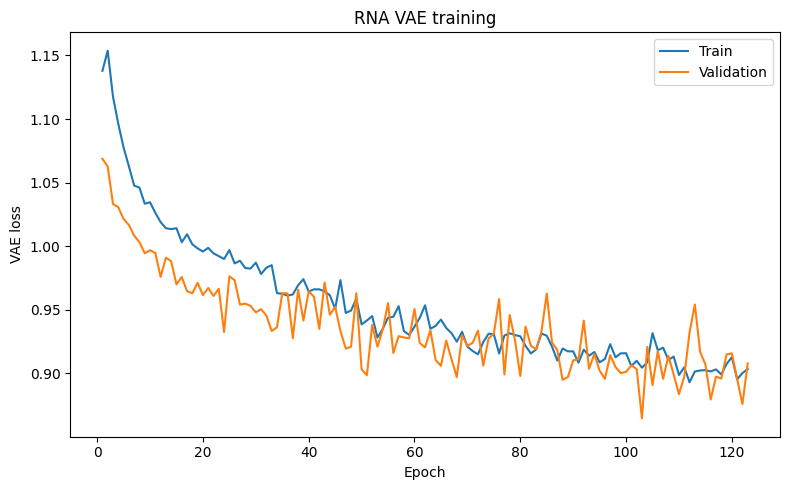

In [157]:
# Plot the losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    rna_history["epoch"],
    rna_history["train_loss"],
    label="Train"
)

plt.plot(
    rna_history["epoch"],
    rna_history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("RNA VAE training")
plt.legend()
plt.tight_layout()
plt.show()

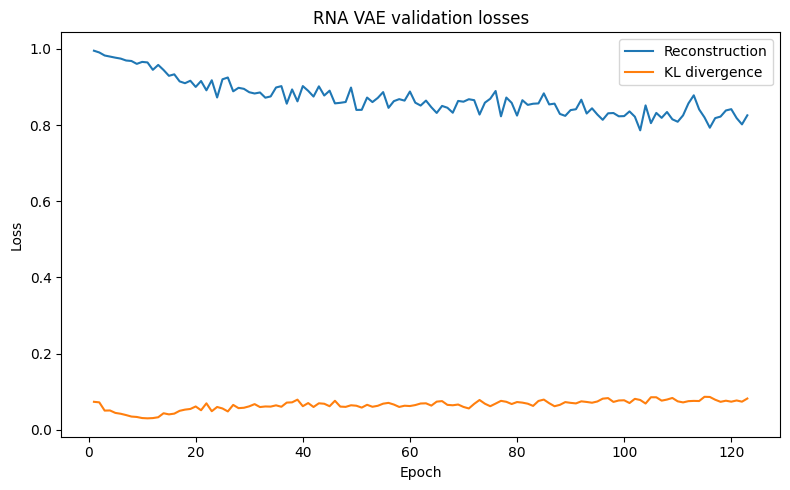

In [158]:
plt.figure(figsize=(8, 5))

plt.plot(
    rna_history["epoch"],
    rna_history["val_reconstruction"],
    label="Reconstruction"
)

plt.plot(
    rna_history["epoch"],
    rna_history["val_kl"],
    label="KL divergence"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RNA VAE validation losses")
plt.legend()
plt.tight_layout()
plt.show()

In [159]:
# Extract the latent representation
def get_latent_mu(model, X_tensor):

    model.eval()

    with torch.no_grad():

        mu, logvar = model.encode(X_tensor)

    return mu.cpu().numpy()

In [160]:
# Extract all three sets
rna_train_latent = get_latent_mu(
    rna_vae,
    X_train_tensor
)

rna_val_latent = get_latent_mu(
    rna_vae,
    X_val_tensor
)

rna_test_latent = get_latent_mu(
    rna_vae,
    X_test_tensor
)

print("Train:", rna_train_latent.shape)
print("Val:", rna_val_latent.shape)
print("Test:", rna_test_latent.shape)

Train: (159, 16)
Val: (40, 16)
Test: (86, 16)


In [161]:
# Convert latent representations to DataFrames
latent_columns = [
    f"RNA_latent_{i+1}"
    for i in range(rna_train_latent.shape[1])
]

rna_latent_train = pd.DataFrame(
    rna_train_latent,
    index=train_samples,
    columns=latent_columns
)

rna_latent_val = pd.DataFrame(
    rna_val_latent,
    index=val_samples,
    columns=latent_columns
)

rna_latent_test = pd.DataFrame(
    rna_test_latent,
    index=test_samples,
    columns=latent_columns
)

In [162]:
print(rna_latent_train.shape)
print(rna_latent_train.head())

(159, 16)
                     RNA_latent_1  RNA_latent_2  RNA_latent_3  RNA_latent_4  \
bcr_patient_barcode                                                           
TCGA-BH-A18T            -0.468769     -0.197482     -0.333553     -0.028501   
TCGA-A8-A07W             0.044977      0.146868      0.272891     -0.010050   
TCGA-C8-A12X             0.133973     -0.088672      0.138334     -0.028773   
TCGA-AN-A0FL            -0.027725     -0.438758     -0.326177      0.093969   
TCGA-AO-A0J6            -0.522008     -0.183678     -0.099762     -0.345138   

                     RNA_latent_5  RNA_latent_6  RNA_latent_7  RNA_latent_8  \
bcr_patient_barcode                                                           
TCGA-BH-A18T             1.542168      0.222318      0.243306      0.115108   
TCGA-A8-A07W             0.482839     -0.154537     -0.250174     -0.136710   
TCGA-C8-A12X             0.531048     -0.086777      0.000444      0.040092   
TCGA-AN-A0FL             1.577205      0.

In [163]:
# Visualise the latent space
from sklearn.decomposition import PCA

latent_pca = PCA(
    n_components=2
)

train_latent_2d = latent_pca.fit_transform(
    rna_latent_train
)

print(
    "Variance explained:",
    latent_pca.explained_variance_ratio_
)

Variance explained: [0.442535  0.3508026]


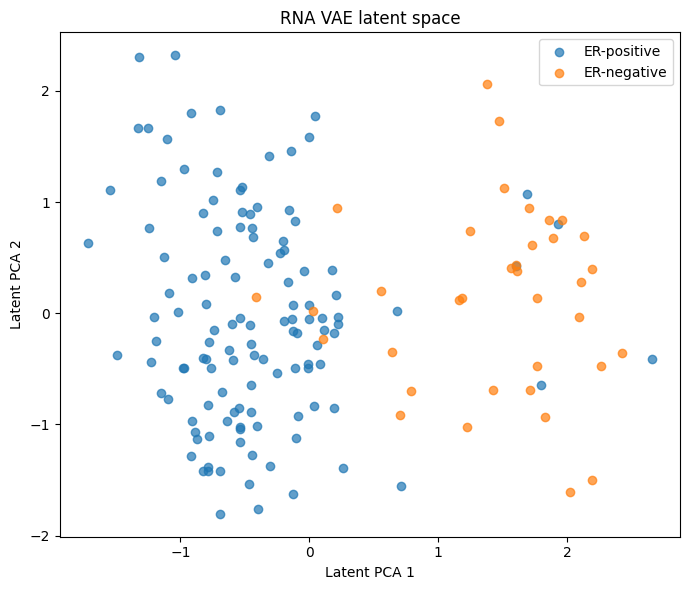

In [164]:
# Plot ER status
plt.figure(figsize=(7, 6))

for status in [0, 1]:

    mask = y_train.to_numpy() == status

    label = (
        "ER-positive"
        if status == 0
        else "ER-negative"
    )

    plt.scatter(
        train_latent_2d[mask, 0],
        train_latent_2d[mask, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("Latent PCA 1")
plt.ylabel("Latent PCA 2")
plt.title("RNA VAE latent space")
plt.legend()
plt.tight_layout()
plt.show()

In [165]:
# Test whether the latent representation predicts ER
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score
)

## RNA VAE classifier
latent_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

latent_classifier.fit(
    rna_latent_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [166]:
val_probability = latent_classifier.predict_proba(
    rna_latent_val
)[:, 1]

val_prediction = (
    val_probability >= 0.5
).astype(int)

print(
    "Validation AUC:",
    roc_auc_score(
        y_val,
        val_probability
    )
)

print(
    "Validation accuracy:",
    accuracy_score(
        y_val,
        val_prediction
    )
)

Validation AUC: 1.0
Validation accuracy: 0.975


In [167]:
 #Check the validation predictions
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y_val,
        val_prediction
    )
)

[[31  0]
 [ 1  8]]


In [168]:
print(
    pd.crosstab(
        y_val,
        val_prediction,
        rownames=["Actual"],
        colnames=["Predicted"]
    )
)

Predicted   0  1
Actual          
0          31  0
1           1  8


In [169]:
# Check the latent coefficients
latent_coefficients = pd.Series(
    latent_classifier.coef_[0],
    index=rna_latent_train.columns
).sort_values(
    key=abs,
    ascending=False
)

print(latent_coefficients)

RNA_latent_15    1.846981
RNA_latent_5     1.234370
RNA_latent_12    0.584893
RNA_latent_2    -0.562539
RNA_latent_13   -0.545888
RNA_latent_4     0.544328
RNA_latent_7    -0.377104
RNA_latent_16    0.373021
RNA_latent_10    0.263522
RNA_latent_1    -0.259029
RNA_latent_6     0.165369
RNA_latent_3     0.162270
RNA_latent_9     0.133701
RNA_latent_8     0.114125
RNA_latent_11   -0.057026
RNA_latent_14    0.002060
dtype: float32


In [170]:
# compare against PCA
from sklearn.decomposition import PCA

pca = PCA(
    n_components=16
)

pca_train = pca.fit_transform(
    X_train_scaled
)

pca_val = pca.transform(
    X_val_scaled
)

pca_test = pca.transform(
    X_test_scaled
)

In [171]:
pca_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pca_classifier.fit(
    pca_train,
    y_train
)

pca_val_probability = pca_classifier.predict_proba(
    pca_val
)[:, 1]

print(
    "PCA validation AUC:",
    roc_auc_score(
        y_val,
        pca_val_probability
    )
)

print(
    "PCA validation accuracy:",
    accuracy_score(
        y_val,
        (pca_val_probability >= 0.5).astype(int)
    )
)

PCA validation AUC: 0.9820788530465949
PCA validation accuracy: 0.925


In [172]:
# Build standard autoencoder
# define autoencoder
import torch
import torch.nn as nn


class RNA_AE(nn.Module):

    def __init__(
        self,
        input_dim,
        hidden_dim=128,
        latent_dim=16
    ):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim)
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        reconstruction = self.decode(z)

        return reconstruction, z

In [173]:
# Define the reconstruction loss
def ae_loss(reconstruction, x):
    return nn.functional.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

In [174]:
# Train the AE
import copy
import numpy as np
import pandas as pd


def train_ae(
    model,
    train_loader,
    val_loader,
    n_epochs=200,
    lr=1e-3,
    patience=20
):

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=1e-5
    )

    history = []

    best_val_loss = np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(n_epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        train_loss = 0.0

        for (x,) in train_loader:

            optimizer.zero_grad()

            reconstruction, z = model(x)

            loss = ae_loss(
                reconstruction,
                x
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        val_loss = 0.0

        with torch.no_grad():

            for (x,) in val_loader:

                reconstruction, z = model(x)

                loss = ae_loss(
                    reconstruction,
                    x
                )

                val_loss += loss.item()

        val_loss /= len(val_loader)

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss
        })

        # -------------------------
        # Early stopping
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_state = copy.deepcopy(
                model.state_dict()
            )

            patience_counter = 0

        else:

            patience_counter += 1

        if (epoch + 1) % 10 == 0:

            print(
                f"Epoch {epoch + 1:3d} | "
                f"Train {train_loss:.4f} | "
                f"Val {val_loss:.4f}"
            )

        if patience_counter >= patience:

            print(
                f"Early stopping at epoch {epoch + 1}"
            )

            break

    # Restore best model
    model.load_state_dict(best_state)

    return model, pd.DataFrame(history)

In [175]:
# Train it using existing RNA loaders
input_dim = X_train_tensor.shape[1]

rna_ae = RNA_AE(
    input_dim=input_dim,
    hidden_dim=128,
    latent_dim=16
)

rna_ae, rna_ae_history = train_ae(
    model=rna_ae,
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=200,
    lr=1e-3,
    patience=20
)

Epoch  10 | Train 0.6688 | Val 0.7077
Epoch  20 | Train 0.5271 | Val 0.6391
Epoch  30 | Train 0.4477 | Val 0.6220
Epoch  40 | Train 0.3891 | Val 0.6187
Epoch  50 | Train 0.3463 | Val 0.6263
Early stopping at epoch 57


In [176]:
# Extract the 16-dimensional latent representation
def get_ae_latent(model, X_tensor):

    model.eval()

    with torch.no_grad():

        z = model.encode(X_tensor)

    return z.cpu().numpy()

In [177]:
ae_train_latent = get_ae_latent(
    rna_ae,
    X_train_tensor
)

ae_val_latent = get_ae_latent(
    rna_ae,
    X_val_tensor
)

ae_test_latent = get_ae_latent(
    rna_ae,
    X_test_tensor
)

In [178]:
print(ae_train_latent.shape)
print(ae_val_latent.shape)
print(ae_test_latent.shape)

(159, 16)
(40, 16)
(86, 16)


In [179]:
# Convert them to DataFrames
latent_columns = [
    f"RNA_AE_latent_{i+1}"
    for i in range(ae_train_latent.shape[1])
]

ae_latent_train = pd.DataFrame(
    ae_train_latent,
    index=train_samples,
    columns=latent_columns
)

ae_latent_val = pd.DataFrame(
    ae_val_latent,
    index=val_samples,
    columns=latent_columns
)

ae_latent_test = pd.DataFrame(
    ae_test_latent,
    index=test_samples,
    columns=latent_columns
)

In [180]:
# Train same downstream classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score


ae_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

ae_classifier.fit(
    ae_latent_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [181]:
# Validation
ae_val_probability = ae_classifier.predict_proba(
    ae_latent_val
)[:, 1]

ae_val_prediction = (
    ae_val_probability >= 0.5
).astype(int)

ae_val_auc = roc_auc_score(
    y_val,
    ae_val_probability
)

ae_val_accuracy = accuracy_score(
    y_val,
    ae_val_prediction
)

print("AE validation AUC:", ae_val_auc)
print("AE validation accuracy:", ae_val_accuracy)

AE validation AUC: 1.0
AE validation accuracy: 0.975


In [182]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_val, ae_val_prediction))

print("AE probabilities:")
print(
    pd.DataFrame({
        "sample": val_samples,
        "true": y_val.values,
        "probability": ae_val_probability,
        "prediction": ae_val_prediction
    }).sort_values("probability")
)

[[30  1]
 [ 0  9]]
AE probabilities:
          sample  true   probability  prediction
3   TCGA-BH-A18N     0  8.165927e-07           0
6   TCGA-E2-A15C     0  3.063248e-06           0
22  TCGA-A8-A08S     0  3.191160e-06           0
28  TCGA-BH-A0HO     0  1.295069e-05           0
32  TCGA-A2-A04V     0  1.421596e-05           0
0   TCGA-B6-A0IM     0  1.576155e-05           0
21  TCGA-AN-A0FF     0  2.042532e-05           0
20  TCGA-BH-A18I     0  2.304001e-05           0
12  TCGA-A8-A096     0  2.773191e-05           0
29  TCGA-BH-A18S     0  3.852956e-05           0
2   TCGA-A2-A0CU     0  3.944138e-05           0
4   TCGA-AO-A0J7     0  9.749259e-05           0
36  TCGA-BH-A0DO     0  9.978291e-05           0
27  TCGA-AN-A049     0  1.037806e-04           0
31  TCGA-A8-A095     0  1.914874e-04           0
37  TCGA-A8-A08F     0  4.523116e-04           0
17  TCGA-A2-A0CP     0  4.746662e-04           0
15  TCGA-B6-A0X0     0  5.018691e-04           0
18  TCGA-AN-A0FZ     0  5.684388

In [183]:
vae_val_probability = latent_classifier.predict_proba(
    rna_latent_val
)[:, 1]

vae_val_prediction = (
    vae_val_probability >= 0.5
).astype(int)

print(confusion_matrix(y_val, vae_val_prediction))

[[31  0]
 [ 1  8]]


In [184]:
# AE test performance
ae_test_probability = ae_classifier.predict_proba(
    ae_latent_test
)[:, 1]

ae_test_prediction = (
    ae_test_probability >= 0.5
).astype(int)

ae_test_auc = roc_auc_score(
    y_test,
    ae_test_probability
)

ae_test_accuracy = accuracy_score(
    y_test,
    ae_test_prediction
)

print("AE test AUC:", ae_test_auc)
print("AE test accuracy:", ae_test_accuracy)

AE test AUC: 0.9968578161822467
AE test accuracy: 0.9534883720930233


In [185]:
# VAE test performance
vae_test_probability = latent_classifier.predict_proba(
    rna_latent_test
)[:, 1]

vae_test_prediction = (
    vae_test_probability >= 0.5
).astype(int)

vae_test_auc = roc_auc_score(
    y_test,
    vae_test_probability
)

vae_test_accuracy = accuracy_score(
    y_test,
    vae_test_prediction
)

print("VAE test AUC:", vae_test_auc)
print("VAE test accuracy:", vae_test_accuracy)

VAE test AUC: 0.9937156323644933
VAE test accuracy: 0.9302325581395349


In [186]:
# PCA test performance
pca_test_probability = pca_classifier.predict_proba(
    pca_test
)[:, 1]

pca_test_prediction = (
    pca_test_probability >= 0.5
).astype(int)

pca_test_auc = roc_auc_score(
    y_test,
    pca_test_probability
)

pca_test_accuracy = accuracy_score(
    y_test,
    pca_test_prediction
)

print("PCA test AUC:", pca_test_auc)
print("PCA test accuracy:", pca_test_accuracy)

PCA test AUC: 0.9984289080911233
PCA test accuracy: 0.9534883720930233


In [187]:
# Put everything together
comparison = pd.DataFrame({
    "Representation": ["PCA", "AE", "VAE"],
    "Latent_dimension": [16, 16, 16],
    "Validation_AUC": [
        0.9820788530,
        ae_val_auc,
        1.0
    ],
    "Validation_accuracy": [
        0.925,
        ae_val_accuracy,
        0.975
    ],
    "Test_AUC": [
        pca_test_auc,
        ae_test_auc,
        vae_test_auc
    ],
    "Test_accuracy": [
        pca_test_accuracy,
        ae_test_accuracy,
        vae_test_accuracy
    ]
})

print(comparison)

  Representation  Latent_dimension  Validation_AUC  Validation_accuracy  \
0            PCA                16        0.982079                0.925   
1             AE                16        1.000000                0.975   
2            VAE                16        1.000000                0.975   

   Test_AUC  Test_accuracy  
0  0.998429       0.953488  
1  0.996858       0.953488  
2  0.993716       0.930233  


In [188]:
# calculate the test confusion matrices and sensitivity/specificity for all three
from sklearn.metrics import confusion_matrix

for name, prediction in [
    ("PCA", pca_test_prediction),
    ("AE", ae_test_prediction),
    ("VAE", vae_test_prediction)
]:
    
    cm = confusion_matrix(y_test, prediction)

    print(f"\n{name}")
    print(cm)


PCA
[[67  0]
 [ 4 15]]

AE
[[66  1]
 [ 3 16]]

VAE
[[67  0]
 [ 6 13]]


In [190]:
from sklearn.metrics import confusion_matrix

for name, prediction in [
    ("PCA", pca_test_prediction),
    ("AE", ae_test_prediction),
    ("VAE", vae_test_prediction)
]:

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        prediction
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    print(f"\n{name}")
    print("TN:", tn)
    print("FP:", fp)
    print("FN:", fn)
    print("TP:", tp)
    print("Sensitivity:", sensitivity)
    print("Specificity:", specificity)


PCA
TN: 67
FP: 0
FN: 4
TP: 15
Sensitivity: 0.7894736842105263
Specificity: 1.0

AE
TN: 66
FP: 1
FN: 3
TP: 16
Sensitivity: 0.8421052631578947
Specificity: 0.9850746268656716

VAE
TN: 67
FP: 0
FN: 6
TP: 13
Sensitivity: 0.6842105263157895
Specificity: 1.0


In [240]:
cnv_train_latent

array([[ 0.57019013, -0.7596373 , -0.37565738, ...,  0.45557922,
         0.27593622,  0.08238762],
       [ 0.06556947,  0.26299366, -0.01023122, ..., -0.47287807,
        -0.27831438,  0.07048153],
       [-0.1981052 , -0.04424477, -0.07229841, ..., -0.2115997 ,
        -0.06731205,  0.1279199 ],
       ...,
       [ 0.14519443, -0.05175369,  0.0871581 , ...,  0.07142252,
         0.09533992, -0.05287576],
       [-0.02215132,  0.2024438 ,  0.03454052, ..., -0.16172725,
        -0.05383778, -0.05929251],
       [ 0.18132743,  0.2740206 , -0.1020055 , ..., -0.16676085,
        -0.13933039, -0.20316558]], shape=(159, 16), dtype=float32)

In [248]:
# remove features with insufficient training data
valid_features_cnv = X_cnv_train.columns[
    X_cnv_train.notna().sum() > 1
]

X_cnv_train_qc = X_cnv_train[
    valid_features_cnv
].copy()

X_cnv_val_qc = X_cnv_val[
    valid_features_cnv
].copy()

X_cnv_test_qc = X_cnv_test[
    valid_features_cnv
].copy()

print("Original features:", X_cnv_train.shape[1])
print("After missingness QC:", X_cnv_train_qc.shape[1])

Original features: 3765
After missingness QC: 3764


In [249]:
# Median imputation
cnv_imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed_cnv = cnv_imputer.fit_transform(
    X_cnv_train_qc
)

X_val_imputed_cnv = cnv_imputer.transform(
    X_cnv_val_qc
)

X_test_imputed_cnv = cnv_imputer.transform(
    X_cnv_test_qc
)

In [250]:
print(
    "Train NaN:",
    np.isnan(X_train_imputed_cnv).sum()
)

print(
    "Val NaN:",
    np.isnan(X_val_imputed_cnv).sum()
)

print(
    "Test NaN:",
    np.isnan(X_test_imputed_cnv).sum()
)

Train NaN: 0
Val NaN: 0
Test NaN: 0


In [251]:
## Variance filtering
variance_selector_cnv = VarianceThreshold(
    threshold=0.05
)

X_train_var_cnv = variance_selector_cnv.fit_transform(
    X_train_imputed_cnv
)

X_val_var_cnv = variance_selector_cnv.transform(
    X_val_imputed_cnv
)

X_test_var_cnv = variance_selector_cnv.transform(
    X_test_imputed_cnv
)

In [252]:
selected_genes_cnv = X_cnv_train_qc.columns[
    variance_selector_cnv.get_support()
]

print(
    "Features after variance filtering:",
    len(selected_genes_cnv)
)

Features after variance filtering: 3021


In [253]:
# Standardise
cnv_scaler = StandardScaler()

X_train_scaled_cnv = cnv_scaler.fit_transform(
    X_train_var_cnv
)

X_val_scaled_cnv = cnv_scaler.transform(
    X_val_var_cnv
)

X_test_scaled_cnv = cnv_scaler.transform(
    X_test_var_cnv
)

In [255]:
print("Train:", X_train_scaled_cnv.shape)
print("Val:", X_val_scaled_cnv.shape)
print("Test:", X_test_scaled_cnv.shape)

print(
    "All finite:",
    np.isfinite(X_train_scaled_cnv).all(),
    np.isfinite(X_val_scaled_cnv).all(),
    np.isfinite(X_test_scaled_cnv).all())

Train: (159, 3021)
Val: (40, 3021)
Test: (86, 3021)
All finite: True True True


In [256]:
# Create CNV tensors
from torch.utils.data import TensorDataset, DataLoader

X_train_cnv_tensor = torch.tensor(
    X_train_scaled_cnv,
    dtype=torch.float32
)

X_val_cnv_tensor = torch.tensor(
    X_val_scaled_cnv,
    dtype=torch.float32
)

X_test_cnv_tensor = torch.tensor(
    X_test_scaled_cnv,
    dtype=torch.float32
)

print(X_train_cnv_tensor.shape)
print(X_val_cnv_tensor.shape)
print(X_test_cnv_tensor.shape)

torch.Size([159, 3021])
torch.Size([40, 3021])
torch.Size([86, 3021])


In [257]:
# Create CNV-specific DataLoaders
train_dataset_cnv = TensorDataset(
    X_train_cnv_tensor
)

val_dataset_cnv = TensorDataset(
    X_val_cnv_tensor
)

test_dataset_cnv = TensorDataset(
    X_test_cnv_tensor
)

train_loader_cnv = DataLoader(
    train_dataset_cnv,
    batch_size=32,
    shuffle=True
)

val_loader_cnv = DataLoader(
    val_dataset_cnv,
    batch_size=32,
    shuffle=False
)

test_loader_cnv = DataLoader(
    test_dataset_cnv,
    batch_size=32,
    shuffle=False
)

In [258]:
input_dim_cnv = X_train_cnv_tensor.shape[1]

cnv_vae = RNA_VAE(
    input_dim=input_dim_cnv,
    hidden_dim=128,
    latent_dim=16
)

print(cnv_vae)

RNA_VAE(
  (encoder): Sequential(
    (0): Linear(in_features=3021, out_features=128, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=3021, bias=True)
  )
)


In [259]:
cnv_vae, cnv_history = train_vae(
    model=cnv_vae,
    train_loader=train_loader_cnv,
    val_loader=val_loader_cnv,
    n_epochs=200,
    lr=1e-3,
    beta=1.0,
    patience=20
)

Epoch  10 | Train 1.0228 | Val 1.2003 | Recon 1.1794 | KL 0.0209
Epoch  20 | Train 1.0116 | Val 1.1861 | Recon 1.1676 | KL 0.0185
Epoch  30 | Train 1.0078 | Val 1.1712 | Recon 1.1509 | KL 0.0203
Epoch  40 | Train 1.0050 | Val 1.1847 | Recon 1.1563 | KL 0.0284
Epoch  50 | Train 1.0029 | Val 1.1724 | Recon 1.1316 | KL 0.0408
Epoch  60 | Train 1.0043 | Val 1.1674 | Recon 1.1233 | KL 0.0441
Epoch  70 | Train 0.9930 | Val 1.1481 | Recon 1.1054 | KL 0.0427
Epoch  80 | Train 0.9866 | Val 1.1680 | Recon 1.1214 | KL 0.0466
Epoch  90 | Train 0.9853 | Val 1.1488 | Recon 1.1114 | KL 0.0374
Epoch 100 | Train 0.9819 | Val 1.1566 | Recon 1.1224 | KL 0.0342
Early stopping at epoch 101


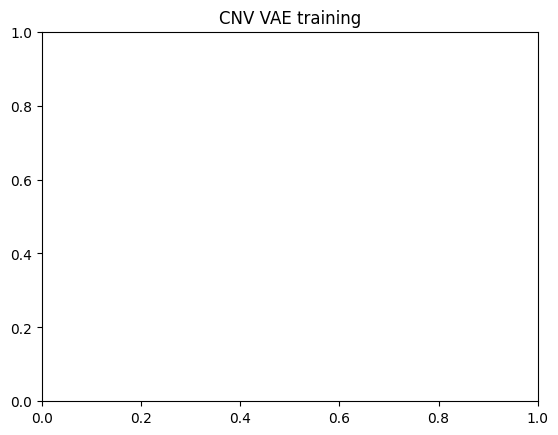

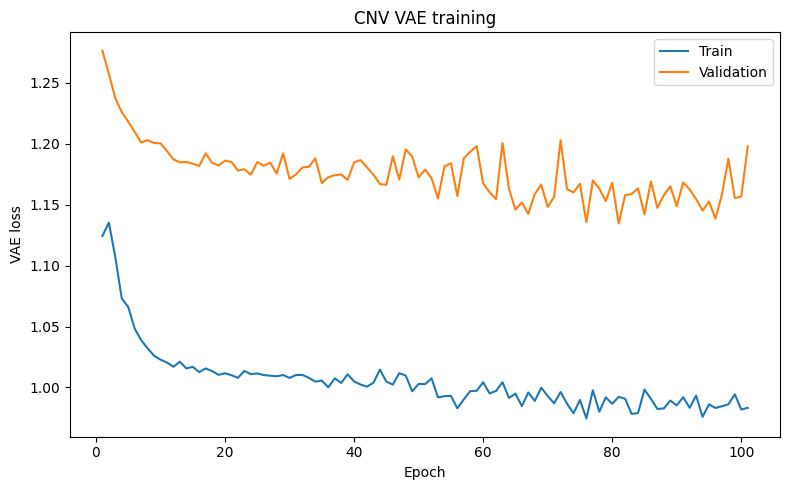

In [267]:
plt.title("CNV VAE training")
plt.figure(figsize=(8, 5))

plt.plot(
    cnv_history["epoch"],
    cnv_history["train_loss"],
    label="Train"
)

plt.plot(
    cnv_history["epoch"],
    cnv_history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("CNV VAE training")
plt.legend()
plt.tight_layout()
plt.show()

In [268]:
# Extract the CNV latent representation
cnv_train_latent = get_latent_mu(
    cnv_vae,
    X_train_cnv_tensor
)

cnv_val_latent = get_latent_mu(
    cnv_vae,
    X_val_cnv_tensor
)

cnv_test_latent = get_latent_mu(
    cnv_vae,
    X_test_cnv_tensor
)

In [269]:
print("Train:", cnv_train_latent.shape)
print("Val:", cnv_val_latent.shape)
print("Test:", cnv_test_latent.shape)


Train: (159, 16)
Val: (40, 16)
Test: (86, 16)


In [270]:
# Convert CNV latent representations to DataFrames
latent_columns = [
    f"CNV_latent_{i+1}"
    for i in range(cnv_train_latent.shape[1])
]

cnv_latent_train = pd.DataFrame(
    cnv_train_latent,
    index=train_samples,
    columns=latent_columns
)

cnv_latent_val = pd.DataFrame(
    cnv_val_latent,
    index=val_samples,
    columns=latent_columns
)

cnv_latent_test = pd.DataFrame(
    cnv_test_latent,
    index=test_samples,
    columns=latent_columns
)

In [271]:
# Test whether the latent CNV representation predicts ER
latent_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

latent_classifier.fit(
    cnv_latent_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [272]:
val_probability_cnv = latent_classifier.predict_proba(
    cnv_latent_val
)[:, 1]

val_prediction_cnv = (
    val_probability_cnv >= 0.5
).astype(int)

print(
    "Validation AUC:",
    roc_auc_score(
        y_val,
        val_probability_cnv
    )
)

print(
    "Validation accuracy:",
    accuracy_score(
        y_val,
        val_prediction_cnv
    )
)

Validation AUC: 0.974910394265233
Validation accuracy: 0.925


In [273]:
#Check the validation predictions
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y_val,
        val_prediction_cnv
    )
)

[[30  1]
 [ 2  7]]


In [274]:
# AE test performance
ae_test_probability = ae_classifier.predict_proba(
    ae_latent_test
)[:, 1]

ae_test_prediction = (
    ae_test_probability >= 0.5
).astype(int)

ae_test_auc = roc_auc_score(
    y_test,
    ae_test_probability
)

ae_test_accuracy = accuracy_score(
    y_test,
    ae_test_prediction
)

print("AE test AUC:", ae_test_auc)
print("AE test accuracy:", ae_test_accuracy)

AE test AUC: 0.9968578161822467
AE test accuracy: 0.9534883720930233


In [275]:
# methylation feature filtering
# remove genes with zero/near-zero variance
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.05)

X_train_var_meth = variance_selector.fit_transform(X_meth_train)
X_val_var_meth = variance_selector.transform(X_meth_val)
X_test_var_meth = variance_selector.transform(X_meth_test)

selected_genes_meth = X_meth_train.columns[
    variance_selector.get_support()
]

print("Original features:", X_meth_train.shape[1])
print("Selected features:", len(selected_genes_meth))

Original features: 17391
Selected features: 1209


In [276]:
X_train_var_meth

array([[0.62491293, 0.78074186, 0.03454449, ..., 0.06571997, 0.73006493,
        0.75064625],
       [0.24651605, 0.70157685, 0.61247513, ..., 0.09265196, 0.29546296,
        0.58448925],
       [0.49153189, 0.83322586, 0.83385459, ..., 0.71372759, 0.7402075 ,
        0.85712994],
       ...,
       [0.07805707, 0.23527093, 0.03556423, ..., 0.59963006, 0.55357157,
        0.6081163 ],
       [0.41160745, 0.75148193, 0.0515097 , ..., 0.17784603, 0.31623622,
        0.56238055],
       [0.18187298, 0.63772611, 0.03130395, ..., 0.06320536, 0.2435367 ,
        0.34077731]], shape=(159, 1209))

In [277]:
## Scale the meth variables
from sklearn.preprocessing import StandardScaler

rna_scaler = StandardScaler()

X_train_scaled_meth = rna_scaler.fit_transform(X_train_var_meth)
X_val_scaled_meth   = rna_scaler.transform(X_val_var_meth)
X_test_scaled_meth  = rna_scaler.transform(X_test_var_meth)

print("Train:", X_train_scaled_meth.shape)
print("Val:", X_val_scaled_meth.shape)
print("Test:", X_test_scaled_meth.shape)

Train: (159, 1209)
Val: (40, 1209)
Test: (86, 1209)


In [278]:
X_train_scaled_meth

array([[ 1.57898375,  1.13148288, -0.74790878, ..., -1.73395457,
         1.01600821,  1.04835136],
       [-0.04548113,  0.83896917,  1.72465167, ..., -1.61651347,
        -0.63591786,  0.31019872],
       [ 1.00637646,  1.32541058,  2.67177933, ...,  1.09178297,
         1.05456021,  1.52140524],
       ...,
       [-0.76867866, -0.88402519, -0.74354601, ...,  0.59424299,
         0.34515532,  0.41516192],
       [ 0.66325932,  1.02336782, -0.6753265 , ..., -1.24501153,
        -0.55695852,  0.21198082],
       [-0.32299502,  0.60304152, -0.76177277, ..., -1.74491993,
        -0.83329005, -0.77249175]], shape=(159, 1209))

In [279]:
# Convert scaled matrix to tensor for model building
X_train_meth_tensor = torch.tensor(
    X_train_scaled_meth,
    dtype=torch.float32
)

X_val_meth_tensor = torch.tensor(
    X_val_scaled_meth,
    dtype=torch.float32
)

X_test_meth_tensor = torch.tensor(
    X_test_scaled_meth,
    dtype=torch.float32
)

print(X_train_meth_tensor.shape)
print(X_val_meth_tensor.shape)
print(X_test_meth_tensor.shape)

torch.Size([159, 1209])
torch.Size([40, 1209])
torch.Size([86, 1209])


In [282]:
# Create DataLoaders
train_dataset_meth = TensorDataset(X_train_meth_tensor)
val_dataset_meth = TensorDataset(X_val_meth_tensor)
test_dataset_meth = TensorDataset(X_test_meth_tensor)

train_loader_meth = DataLoader(
    train_dataset_meth,
    batch_size=32,
    shuffle=True
)

val_loader_meth = DataLoader(
    val_dataset_meth,
    batch_size=32,
    shuffle=False
)

test_loader_meth = DataLoader(
    test_dataset_meth,
    batch_size=32,
    shuffle=False
)


In [283]:
input_dim_meth = X_train_meth_tensor.shape[1]

meth_vae = RNA_VAE(
    input_dim=input_dim_meth,
    hidden_dim=128,
    latent_dim=16
)

print(meth_vae)


# Train it using existing meth loaders
input_dim = X_train_meth_tensor.shape[1]

meth_ae = RNA_AE(
    input_dim=input_dim_meth,
    hidden_dim=128,
    latent_dim=16
)

meth_ae, meth_ae_history = train_ae(
    model=meth_ae,
    train_loader=train_loader_meth,
    val_loader=val_loader_meth,
    n_epochs=200,
    lr=1e-3,
    patience=20
)

RNA_VAE(
  (encoder): Sequential(
    (0): Linear(in_features=1209, out_features=128, bias=True)
    (1): ReLU()
  )
  (fc_mu): Linear(in_features=128, out_features=16, bias=True)
  (fc_logvar): Linear(in_features=128, out_features=16, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1209, bias=True)
  )
)
Epoch  10 | Train 0.5784 | Val 0.6017
Epoch  20 | Train 0.4674 | Val 0.5533
Epoch  30 | Train 0.4045 | Val 0.5424
Epoch  40 | Train 0.3567 | Val 0.5457
Epoch  50 | Train 0.3164 | Val 0.5521
Early stopping at epoch 52


In [284]:
# Impute meth using training data only since there is missingness
from sklearn.impute import SimpleImputer

meth_imputer = SimpleImputer(
    strategy="median"
)

X_train_imputed_meth = meth_imputer.fit_transform(
    X_train_var_meth
)

X_val_imputed_meth = meth_imputer.transform(
    X_val_var_meth
)

X_test_imputed_meth = meth_imputer.transform(
    X_test_var_meth
)


In [285]:
from sklearn.preprocessing import StandardScaler

rna_scaler = StandardScaler()

X_train_scaled_meth = rna_scaler.fit_transform(X_train_imputed_meth)
X_val_scaled_meth   = rna_scaler.transform(X_val_imputed_meth)
X_test_scaled_meth  = rna_scaler.transform(X_test_imputed_meth)

print("Train:", X_train_scaled_meth.shape)
print("Val:", X_val_scaled_meth.shape)
print("Test:", X_test_scaled_meth.shape)


Train: (159, 1209)
Val: (40, 1209)
Test: (86, 1209)


In [286]:
X_train_meth_tensor = torch.tensor(
    X_train_scaled_meth,
    dtype=torch.float32
)

X_val_meth_tensor = torch.tensor(
    X_val_scaled_meth,
    dtype=torch.float32
)

X_test_meth_tensor = torch.tensor(
    X_test_scaled_meth,
    dtype=torch.float32
)


In [287]:
train_dataset_meth = TensorDataset(
    X_train_meth_tensor
)

val_dataset_meth = TensorDataset(
    X_val_meth_tensor
)

test_dataset_meth = TensorDataset(
    X_test_meth_tensor
)

train_loader_meth = DataLoader(
    train_dataset_meth,
    batch_size=32,
    shuffle=True
)

In [288]:
val_loader_meth = DataLoader(
    val_dataset_meth,
    batch_size=32,
    shuffle=False
)

test_loader_meth = DataLoader(
    test_dataset_meth,
    batch_size=32,
    shuffle=False
)

In [289]:
input_dim_meth = X_train_meth_tensor.shape[1]

meth_vae = RNA_VAE(
    input_dim=input_dim_meth,
    hidden_dim=128,
    latent_dim=16
)


meth_vae, meth_history = train_vae(
    model=meth_vae,
    train_loader=train_loader_meth,
    val_loader=val_loader_meth,
    n_epochs=200,
    lr=1e-3,
    beta=1.0,
    patience=20
)


Epoch  10 | Train 0.9805 | Val 0.8874 | Recon 0.8352 | KL 0.0521
Epoch  20 | Train 0.9131 | Val 0.8667 | Recon 0.7945 | KL 0.0721
Epoch  30 | Train 0.8893 | Val 0.8117 | Recon 0.7393 | KL 0.0723
Epoch  40 | Train 0.8652 | Val 0.8773 | Recon 0.8185 | KL 0.0588
Epoch  50 | Train 0.8599 | Val 0.8072 | Recon 0.7382 | KL 0.0690
Epoch  60 | Train 0.8482 | Val 0.8261 | Recon 0.7428 | KL 0.0834
Epoch  70 | Train 0.8247 | Val 0.7792 | Recon 0.6999 | KL 0.0793
Epoch  80 | Train 0.8149 | Val 0.8164 | Recon 0.7433 | KL 0.0731
Epoch  90 | Train 0.8012 | Val 0.7734 | Recon 0.6996 | KL 0.0738
Epoch 100 | Train 0.8114 | Val 0.7933 | Recon 0.7151 | KL 0.0782
Epoch 110 | Train 0.8121 | Val 0.8356 | Recon 0.7530 | KL 0.0826
Early stopping at epoch 113


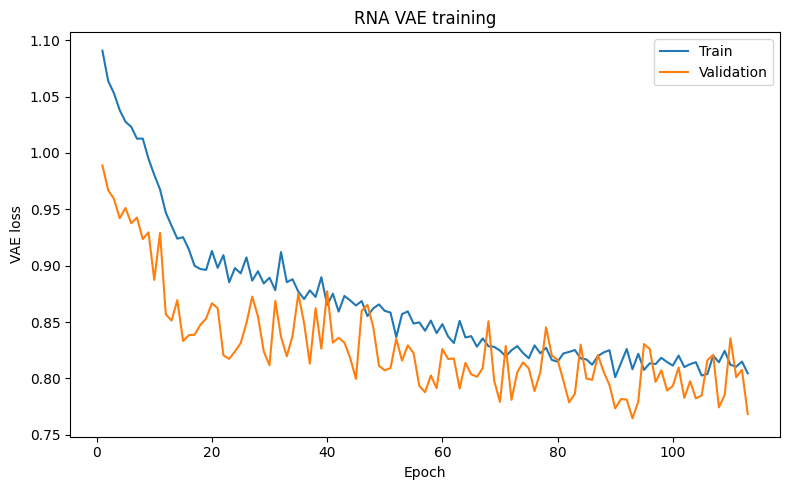

In [290]:
# Plot the meth losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    meth_history["epoch"],
    meth_history["train_loss"],
    label="Train"
)

plt.plot(
    meth_history["epoch"],
    meth_history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("VAE loss")
plt.title("RNA VAE training")
plt.legend()
plt.tight_layout()
plt.show()

In [291]:
# Extract all three meth latent representations
meth_train_latent = get_latent_mu(
    meth_vae,
    X_train_meth_tensor
)

meth_val_latent = get_latent_mu(
    meth_vae,
    X_val_meth_tensor
)

meth_test_latent = get_latent_mu(
    meth_vae,
    X_test_meth_tensor
)

print("Train:", meth_train_latent.shape)
print("Val:", meth_val_latent.shape)
print("Test:", meth_test_latent.shape)

Train: (159, 16)
Val: (40, 16)
Test: (86, 16)


In [292]:
# Convert meth latent representations to DataFrames
latent_columns = [
    f"meth_latent_{i+1}"
    for i in range(meth_train_latent.shape[1])
]

meth_latent_train = pd.DataFrame(
    meth_train_latent,
    index=train_samples,
    columns=latent_columns
)

meth_latent_val = pd.DataFrame(
    meth_val_latent,
    index=val_samples,
    columns=latent_columns
)

meth_latent_test = pd.DataFrame(
    meth_test_latent,
    index=test_samples,
    columns=latent_columns
)



In [293]:
# Test whether the latent meth representation predicts ER
latent_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

latent_classifier.fit(
    meth_latent_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [294]:
val_probability_meth = latent_classifier.predict_proba(
    meth_latent_val
)[:, 1]

val_prediction_meth = (
    val_probability_meth >= 0.5
).astype(int)

print(
    "Validation AUC:",
    roc_auc_score(
        y_val,
        val_probability_meth
    )
)

print(
    "Validation accuracy:",
    accuracy_score(
        y_val,
        val_prediction_meth
    )
)

Validation AUC: 1.0
Validation accuracy: 0.95


In [295]:
#Check the validation predictions
from sklearn.metrics import confusion_matrix

print(
    confusion_matrix(
        y_val,
        val_prediction_meth
    )
)

[[31  0]
 [ 2  7]]


In [296]:
rna_latent_train
rna_latent_val
rna_latent_test

cnv_latent_train
cnv_latent_val
cnv_latent_test

meth_latent_train
meth_latent_val
meth_latent_test

,meth_latent_1,meth_latent_2,meth_latent_3,meth_latent_4,meth_latent_5,meth_latent_6,meth_latent_7,meth_latent_8,meth_latent_9,meth_latent_10,meth_latent_11,meth_latent_12,meth_latent_13,meth_latent_14,meth_latent_15,meth_latent_16
bcr_patient_barcode,,,,,,,,,,,,,,,,
TCGA-E2-A14Z,-0.088848,-0.196646,0.216591,0.015774,0.039819,-0.044131,0.261107,0.079200,-0.188630,0.139768,-0.098275,0.064456,0.374637,-0.144715,-0.221682,0.057067
TCGA-AO-A0J2,-0.097903,-0.045274,0.035118,-0.015062,0.135160,-0.146044,0.095685,-0.001396,-0.820678,-0.160292,0.065015,-0.056605,0.392183,0.010604,0.091320,-0.302131
TCGA-E2-A15H,-0.305809,0.078170,0.110694,-0.209120,0.070817,0.113466,0.132491,0.171689,-0.481699,-0.099443,-0.060582,-0.013209,0.347335,-0.446917,0.184201,-0.226935
TCGA-A8-A097,0.099735,0.053324,0.309054,0.215633,-0.419790,-0.096178,-0.796531,0.655317,-0.205502,0.217131,-0.010525,0.113958,-0.641218,-0.158653,-0.046150,0.422007
TCGA-AN-A0AJ,-0.057489,0.162060,-0.103245,0.028687,-0.224820,0.014982,-0.126844,0.245553,1.861957,-0.033749,-0.054658,0.100330,-0.169524,0.055724,-0.121838,-0.018236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-A8-A081,0.165748,0.019048,0.307163,0.133034,-0.553740,-0.070345,-0.502730,0.800838,0.794365,0.231583,0.020750,0.018146,-0.864133,0.021114,-0.308607,0.422731
TCGA-AO-A12D,-0.124058,-0.104605,0.080743,-0.283365,0.127210,0.139056,0.152042,-0.188754,-0.929892,-0.225201,-0.108001,-0.126180,0.454095,-0.051883,0.067543,-0.128844
TCGA-E2-A14V,0.065987,-0.046301,-0.063652,-0.009470,-0.306490,-0.008349,-0.092464,0.155801,0.542939,0.153640,0.083043,0.053267,-0.349145,-0.107432,-0.293511,0.168182


In [297]:
## I now have VAE 
assert rna_latent_train.index.equals(cnv_latent_train.index)
assert rna_latent_train.index.equals(meth_latent_train.index)

assert rna_latent_val.index.equals(cnv_latent_val.index)
assert rna_latent_val.index.equals(meth_latent_val.index)

assert rna_latent_test.index.equals(cnv_latent_test.index)
assert rna_latent_test.index.equals(meth_latent_test.index)

In [298]:
latent_train = pd.concat(
    [
        rna_latent_train,
        cnv_latent_train,
        meth_latent_train
    ],
    axis=1
)

latent_val = pd.concat(
    [
        rna_latent_val,
        cnv_latent_val,
        meth_latent_val
    ],
    axis=1
)

latent_test = pd.concat(
    [
        rna_latent_test,
        cnv_latent_test,
        meth_latent_test
    ],
    axis=1
)

In [299]:
latent_train

,RNA_latent_1,RNA_latent_2,RNA_latent_3,RNA_latent_4,RNA_latent_5,RNA_latent_6,RNA_latent_7,RNA_latent_8,RNA_latent_9,RNA_latent_10,...,meth_latent_7,meth_latent_8,meth_latent_9,meth_latent_10,meth_latent_11,meth_latent_12,meth_latent_13,meth_latent_14,meth_latent_15,meth_latent_16
bcr_patient_barcode,,,,,,,,,,,,,,,,,,,,,
TCGA-BH-A18T,-0.468769,-0.197482,-0.333553,-0.028501,1.542168,0.222318,0.243306,0.115108,0.044544,-0.051386,...,0.102059,-0.330421,-1.583425,0.190779,-0.136711,0.116940,0.191397,0.675087,-0.269062,0.179269
TCGA-A8-A07W,0.044977,0.146868,0.272891,-0.010050,0.482839,-0.154537,-0.250174,-0.136710,-0.249300,0.150319,...,-1.015903,0.936892,0.678719,0.194452,-0.076966,0.014769,-1.011258,0.038238,0.001152,0.457114
TCGA-C8-A12X,0.133973,-0.088672,0.138334,-0.028773,0.531048,-0.086777,0.000444,0.040092,0.018571,-0.078195,...,0.044736,-0.645967,2.179526,-0.291776,-0.040321,-0.285010,0.424767,0.281536,0.217576,-0.383487
TCGA-AN-A0FL,-0.027725,-0.438758,-0.326177,0.093969,1.577205,0.583804,0.138695,0.454026,0.150116,-0.227725,...,0.086840,-0.155602,-1.626046,0.321111,0.005615,0.091734,-0.109717,0.714840,-0.299007,0.150458
TCGA-AO-A0J6,-0.522008,-0.183678,-0.099762,-0.345138,1.244073,-0.181254,0.455531,-0.232864,-0.018159,0.028504,...,0.477381,-0.589078,0.160436,-0.160083,0.114755,-0.050802,0.391567,0.521944,-0.028961,-0.091222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-D8-A147,-0.477778,-0.258416,-0.251143,-0.081600,0.973635,-0.157488,0.276245,-0.038178,0.098021,0.036747,...,0.016952,-0.085692,-1.913206,0.134364,-0.096464,0.122397,0.002696,0.382785,-0.102795,0.048741
TCGA-D8-A142,-0.376685,0.079358,-0.002356,-0.148336,0.230847,-0.033507,0.160438,-0.198438,-0.042455,0.144875,...,-0.212200,0.252642,-1.534018,0.248741,0.067099,0.058808,-0.202170,0.482689,-0.238109,0.269105
TCGA-A8-A08X,-0.387334,0.182020,0.359235,-0.120619,-0.066435,-0.636051,-0.202619,-0.387629,-0.296991,0.438085,...,0.380141,-0.401688,0.196030,-0.113438,-0.064556,-0.042595,0.418349,0.437457,-0.133925,-0.031327


In [300]:
# Train the downstream classifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

latent_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

latent_classifier.fit(
    latent_train,
    y_train
)

val_probability = latent_classifier.predict_proba(
    latent_val
)[:, 1]

val_prediction = latent_classifier.predict(
    latent_val
)

val_auc = roc_auc_score(
    y_val,
    val_probability
)

val_accuracy = accuracy_score(
    y_val,
    val_prediction
)

print("Validation AUC:", val_auc)
print("Validation accuracy:", val_accuracy)


Validation AUC: 1.0
Validation accuracy: 0.975


In [301]:
test_probability = latent_classifier.predict_proba(
    latent_test
)[:, 1]

test_prediction = latent_classifier.predict(
    latent_test
)

test_auc = roc_auc_score(
    y_test,
    test_probability
)

test_accuracy = accuracy_score(
    y_test,
    test_prediction
)

print("Test AUC:", test_auc)
print("Test accuracy:", test_accuracy)

Test AUC: 0.9890023566378633
Test accuracy: 0.9418604651162791


In [304]:
from sklearn.linear_model import LogisticRegression

rna_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

rna_classifier.fit(
    rna_latent_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [ ]:
##rna test predictions

In [305]:
rna_test_probability = rna_classifier.predict_proba(
    rna_latent_test
)[:, 1]

rna_test_prediction = (
    rna_test_probability >= 0.5
).astype(int)

In [306]:
## multimodal classifier
multi_test_probability = latent_classifier.predict_proba(
    latent_test
)[:, 1
]

multi_test_prediction = (
    multi_test_probability >= 0.5
).astype(int)

In [308]:
comparison = pd.DataFrame({
    "sample": y_test.index,
    "true": y_test.values,

    "RNA_probability": rna_test_probability,
    "RNA_prediction": rna_test_prediction,

    "Multi_probability": multi_test_probability,
    "Multi_prediction": multi_test_prediction
})

In [309]:
comparison

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction
0,TCGA-E2-A14Z,0,0.094629,0,0.100001,0
1,TCGA-AO-A0J2,1,0.572294,1,0.609358,1
2,TCGA-E2-A15H,0,0.037272,0,0.019429,0
3,TCGA-A8-A097,0,0.094399,0,0.011806,0
4,TCGA-AN-A0AJ,0,0.145109,0,0.031370,0
...,...,...,...,...,...,...
81,TCGA-A8-A081,0,0.090651,0,0.013583,0
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1
83,TCGA-E2-A14V,0,0.088931,0,0.026950,0
84,TCGA-AO-A0J8,0,0.026912,0,0.009414,0


In [310]:
comparison["RNA_correct"] = (
    comparison["RNA_prediction"] == comparison["true"]
)

comparison["Multi_correct"] = (
    comparison["Multi_prediction"] == comparison["true"]
)


In [311]:
comparison

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct
0,TCGA-E2-A14Z,0,0.094629,0,0.100001,0,True,True
1,TCGA-AO-A0J2,1,0.572294,1,0.609358,1,True,True
2,TCGA-E2-A15H,0,0.037272,0,0.019429,0,True,True
3,TCGA-A8-A097,0,0.094399,0,0.011806,0,True,True
4,TCGA-AN-A0AJ,0,0.145109,0,0.031370,0,True,True
...,...,...,...,...,...,...,...,...
81,TCGA-A8-A081,0,0.090651,0,0.013583,0,True,True
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1,False,True
83,TCGA-E2-A14V,0,0.088931,0,0.026950,0,True,True
84,TCGA-AO-A0J8,0,0.026912,0,0.009414,0,True,True


In [313]:
comparison["comparison"] = np.select(
    [
        comparison["RNA_correct"] & comparison["Multi_correct"],
        comparison["RNA_correct"] & ~comparison["Multi_correct"],
        ~comparison["RNA_correct"] & comparison["Multi_correct"],
        ~comparison["RNA_correct"] & ~comparison["Multi_correct"]
    ],
    [
        "Both correct",
        "RNA correct, multimodal wrong",
        "RNA wrong, multimodal correct",
        "Both wrong"
    ],
    default="Unknown"
)

In [314]:
comparison

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison
0,TCGA-E2-A14Z,0,0.094629,0,0.100001,0,True,True,Both correct
1,TCGA-AO-A0J2,1,0.572294,1,0.609358,1,True,True,Both correct
2,TCGA-E2-A15H,0,0.037272,0,0.019429,0,True,True,Both correct
3,TCGA-A8-A097,0,0.094399,0,0.011806,0,True,True,Both correct
4,TCGA-AN-A0AJ,0,0.145109,0,0.031370,0,True,True,Both correct
...,...,...,...,...,...,...,...,...,...
81,TCGA-A8-A081,0,0.090651,0,0.013583,0,True,True,Both correct
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1,False,True,"RNA wrong, multimodal correct"
83,TCGA-E2-A14V,0,0.088931,0,0.026950,0,True,True,Both correct
84,TCGA-AO-A0J8,0,0.026912,0,0.009414,0,True,True,Both correct


In [315]:
print(comparison["comparison"].value_counts())

comparison
Both correct                     79
Both wrong                        4
RNA wrong, multimodal correct     2
RNA correct, multimodal wrong     1
Name: count, dtype: int64


In [316]:
## where mutimodal rescued error
multi_rescues = comparison[
    comparison["comparison"] == "RNA wrong, multimodal correct"
]

print(multi_rescues)

          sample  true  RNA_probability  RNA_prediction  Multi_probability  \
67  TCGA-AN-A04C     1         0.390353               0           0.552227   
82  TCGA-AO-A12D     1         0.381965               0           0.500031   

    Multi_prediction  RNA_correct  Multi_correct  \
67                 1        False           True   
82                 1        False           True   

                       comparison  
67  RNA wrong, multimodal correct  
82  RNA wrong, multimodal correct  


In [317]:
multi_failures = comparison[
    comparison["comparison"] == "RNA correct, multimodal wrong"
]

print(multi_failures)

          sample  true  RNA_probability  RNA_prediction  Multi_probability  \
80  TCGA-A8-A08L     0         0.219523               0           0.576247   

    Multi_prediction  RNA_correct  Multi_correct  \
80                 1         True          False   

                       comparison  
80  RNA correct, multimodal wrong  


In [318]:
print(comparison["comparison"].value_counts())

comparison
Both correct                     79
Both wrong                        4
RNA wrong, multimodal correct     2
RNA correct, multimodal wrong     1
Name: count, dtype: int64


In [319]:
print(multi_rescues)
print(multi_failures)

          sample  true  RNA_probability  RNA_prediction  Multi_probability  \
67  TCGA-AN-A04C     1         0.390353               0           0.552227   
82  TCGA-AO-A12D     1         0.381965               0           0.500031   

    Multi_prediction  RNA_correct  Multi_correct  \
67                 1        False           True   
82                 1        False           True   

                       comparison  
67  RNA wrong, multimodal correct  
82  RNA wrong, multimodal correct  
          sample  true  RNA_probability  RNA_prediction  Multi_probability  \
80  TCGA-A8-A08L     0         0.219523               0           0.576247   

    Multi_prediction  RNA_correct  Multi_correct  \
80                 1         True          False   

                       comparison  
80  RNA correct, multimodal wrong  


In [320]:
# confusion matrices
print("RNA VAE")
print(confusion_matrix(y_test, rna_test_prediction))

print("\nRNA + CNV + Methylation VAE")
print(confusion_matrix(y_test, multi_test_prediction))

RNA VAE
[[67  0]
 [ 6 13]]

RNA + CNV + Methylation VAE
[[66  1]
 [ 4 15]]


In [321]:
## sensitivity/specificity
from sklearn.metrics import recall_score

def classification_metrics(y_true, prediction):
    
    cm = confusion_matrix(y_true, prediction)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return {
        "accuracy": accuracy_score(y_true, prediction),
        "sensitivity": sensitivity,
        "specificity": specificity
    }

print(
    "RNA:",
    classification_metrics(y_test, rna_test_prediction)
)

print(
    "Multimodal:",
    classification_metrics(y_test, multi_test_prediction)
)

RNA: {'accuracy': 0.9302325581395349, 'sensitivity': np.float64(0.6842105263157895), 'specificity': np.float64(1.0)}
Multimodal: {'accuracy': 0.9418604651162791, 'sensitivity': np.float64(0.7894736842105263), 'specificity': np.float64(0.9850746268656716)}


In [322]:
# bootstrap the test samples for AUC and accuracy CI
from sklearn.utils import resample

def bootstrap_metrics(
    y_true,
    probability,
    prediction,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    probability = np.asarray(probability)
    prediction = np.asarray(prediction)

    auc_values = []
    accuracy_values = []

    for _ in range(n_bootstrap):

        idx = rng.integers(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[idx]
        prob_boot = probability[idx]
        pred_boot = prediction[idx]

        # AUC requires both classes
        if len(np.unique(y_boot)) < 2:
            continue

        auc_values.append(
            roc_auc_score(
                y_boot,
                prob_boot
            )
        )

        accuracy_values.append(
            accuracy_score(
                y_boot,
                pred_boot
            )
        )

    return {
        "AUC": (
            np.percentile(auc_values, 2.5),
            np.percentile(auc_values, 97.5)
        ),
        "accuracy": (
            np.percentile(accuracy_values, 2.5),
            np.percentile(accuracy_values, 97.5)
        )
    }

In [323]:
# RNA
rna_bootstrap = bootstrap_metrics(
    y_test,
    rna_test_probability,
    rna_test_prediction
)

print(rna_bootstrap)

{'AUC': (np.float64(0.9803921568627451), np.float64(1.0)), 'accuracy': (np.float64(0.872093023255814), np.float64(0.9767441860465116))}


In [324]:
# Multimodal
multi_bootstrap = bootstrap_metrics(
    y_test,
    multi_test_probability,
    multi_test_prediction
)

print(multi_bootstrap)

{'AUC': (np.float64(0.9696345222871758), np.float64(1.0)), 'accuracy': (np.float64(0.8837209302325582), np.float64(0.9883720930232558))}


In [325]:
print(comparison["comparison"].value_counts())

comparison
Both correct                     79
Both wrong                        4
RNA wrong, multimodal correct     2
RNA correct, multimodal wrong     1
Name: count, dtype: int64


In [326]:
print("\nRNA wrong, multimodal correct:")
display(multi_rescues)

print("\nRNA correct, multimodal wrong:")
display(multi_failures)


RNA wrong, multimodal correct:


,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison
67,TCGA-AN-A04C,1,0.390353,0,0.552227,1,False,True,"RNA wrong, multimodal correct"
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1,False,True,"RNA wrong, multimodal correct"



RNA correct, multimodal wrong:


,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison
80,TCGA-A8-A08L,0,0.219523,0,0.576247,1,True,False,"RNA correct, multimodal wrong"


In [327]:
from sklearn.metrics import confusion_matrix

print("RNA VAE")
print(confusion_matrix(y_test, rna_test_prediction))

print("\nMultimodal")
print(confusion_matrix(y_test, multi_test_prediction))

RNA VAE
[[67  0]
 [ 6 13]]

Multimodal
[[66  1]
 [ 4 15]]


In [328]:
# Is the multimodal model is changing predictions mainly for borderline RNA samples:
comparison["RNA_confidence"] = np.abs(
    comparison["RNA_probability"] - 0.5
)

comparison["Multi_confidence"] = np.abs(
    comparison["Multi_probability"] - 0.5
)

display(
    comparison.sort_values("RNA_confidence").head(15)
)

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison,RNA_confidence,Multi_confidence
1,TCGA-AO-A0J2,1,0.572294,1,0.609358,1,True,True,Both correct,0.072294,0.109358
64,TCGA-D8-A13Z,1,0.593178,1,0.701746,1,True,True,Both correct,0.093178,0.201746
67,TCGA-AN-A04C,1,0.390353,0,0.552227,1,False,True,"RNA wrong, multimodal correct",0.109647,0.052227
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1,False,True,"RNA wrong, multimodal correct",0.118035,0.000031
51,TCGA-A8-A0A7,1,0.310311,0,0.316050,0,False,False,Both wrong,0.189689,0.183950
19,TCGA-A8-A08H,0,0.264400,0,0.184730,0,True,True,Both correct,0.235600,0.315270
39,TCGA-AO-A12F,1,0.735691,1,0.858584,1,True,True,Both correct,0.235691,0.358584
80,TCGA-A8-A08L,0,0.219523,0,0.576247,1,True,False,"RNA correct, multimodal wrong",0.280477,0.076247
20,TCGA-A7-A0CE,1,0.786262,1,0.841883,1,True,True,Both correct,0.286262,0.341883
71,TCGA-AN-A0FV,1,0.182125,0,0.117448,0,False,False,Both wrong,0.317875,0.382552


In [329]:
comparison["RNA_margin"] = np.abs(
    comparison["RNA_probability"] - 0.5
)

comparison["Multi_margin"] = np.abs(
    comparison["Multi_probability"] - 0.5
)

In [330]:
# summarise all four groups
comparison["comparison"].value_counts()

comparison
Both correct                     79
Both wrong                        4
RNA wrong, multimodal correct     2
RNA correct, multimodal wrong     1
Name: count, dtype: int64

In [331]:
summary = (
    comparison["comparison"]
    .value_counts()
    .rename_axis("comparison")
    .reset_index(name="n")
)

summary["percentage"] = (
    summary["n"] / len(comparison) * 100
)

summary

,comparison,n,percentage
0,Both correct,79,91.860465
1,Both wrong,4,4.651163
2,"RNA wrong, multimodal correct",2,2.325581
3,"RNA correct, multimodal wrong",1,1.162791


In [332]:
# rescued cases
multi_rescues = comparison[
    comparison["comparison"] == "RNA wrong, multimodal correct"
].copy()

multi_rescues.sort_values("RNA_margin")

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison,RNA_confidence,Multi_confidence,RNA_margin,Multi_margin
67,TCGA-AN-A04C,1,0.390353,0,0.552227,1,False,True,"RNA wrong, multimodal correct",0.109647,0.052227,0.109647,0.052227
82,TCGA-AO-A12D,1,0.381965,0,0.500031,1,False,True,"RNA wrong, multimodal correct",0.118035,0.000031,0.118035,0.000031


In [333]:
multi_failures = comparison[
    comparison["comparison"] == "RNA correct, multimodal wrong"
].copy()

multi_failures.sort_values("RNA_margin", ascending=False)

,sample,true,RNA_probability,RNA_prediction,Multi_probability,Multi_prediction,RNA_correct,Multi_correct,comparison,RNA_confidence,Multi_confidence,RNA_margin,Multi_margin
80,TCGA-A8-A08L,0,0.219523,0,0.576247,1,True,False,"RNA correct, multimodal wrong",0.280477,0.076247,0.280477,0.076247


In [334]:
# examine probability changes
comparison["Multi_minus_RNA"] = (
    comparison["Multi_probability"]
    - comparison["RNA_probability"]
)

comparison[
    [
        "sample",
        "true",
        "RNA_probability",
        "Multi_probability",
        "Multi_minus_RNA",
        "comparison"
    ]
].sort_values("Multi_minus_RNA")

,sample,true,RNA_probability,Multi_probability,Multi_minus_RNA,comparison
72,TCGA-A8-A08J,0,0.147715,0.026601,-0.121115,Both correct
27,TCGA-A2-A0D2,1,0.919974,0.801155,-0.118819,Both correct
4,TCGA-AN-A0AJ,0,0.145109,0.031370,-0.113738,Both correct
3,TCGA-A8-A097,0,0.094399,0.011806,-0.082593,Both correct
19,TCGA-A8-A08H,0,0.264400,0.184730,-0.079670,Both correct
...,...,...,...,...,...,...
64,TCGA-D8-A13Z,1,0.593178,0.701746,0.108569,Both correct
82,TCGA-AO-A12D,1,0.381965,0.500031,0.118066,"RNA wrong, multimodal correct"
39,TCGA-AO-A12F,1,0.735691,0.858584,0.122892,Both correct
67,TCGA-AN-A04C,1,0.390353,0.552227,0.161874,"RNA wrong, multimodal correct"


In [335]:
comparison.groupby("comparison")[
    "Multi_minus_RNA"
].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
comparison,,,,,
Both correct,79,-0.009361,-0.007606,-0.121115,0.122892
Both wrong,4,-0.004961,-0.002217,-0.064677,0.049269
"RNA correct, multimodal wrong",1,0.356724,0.356724,0.356724,0.356724
"RNA wrong, multimodal correct",2,0.139970,0.139970,0.118066,0.161874


In [336]:
comparison.groupby("comparison")[
    "RNA_probability"
].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
comparison,,,,,
Both correct,79,0.171678,0.037272,0.001541,0.938929
Both wrong,4,0.195673,0.170378,0.131623,0.310311
"RNA correct, multimodal wrong",1,0.219523,0.219523,0.219523,0.219523
"RNA wrong, multimodal correct",2,0.386159,0.386159,0.381965,0.390353


In [ ]:
## concatenate CNV and methylation VAEs latent representations in different combinations and train separate downstream classifiers.

In [337]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

models = {
    "RNA": (
        rna_latent_train,
        rna_latent_val
    ),
    "RNA + CNV": (
        pd.concat(
            [rna_latent_train, cnv_latent_train],
            axis=1
        ),
        pd.concat(
            [rna_latent_val, cnv_latent_val],
            axis=1
        )
    ),
    "RNA + Methylation": (
        pd.concat(
            [rna_latent_train, meth_latent_train],
            axis=1
        ),
        pd.concat(
            [rna_latent_val, meth_latent_val],
            axis=1
        )
    ),
    "CNV + Methylation": (
        pd.concat(
            [cnv_latent_train, meth_latent_train],
            axis=1
        ),
        pd.concat(
            [cnv_latent_val, meth_latent_val],
            axis=1
        )
    ),
    "RNA + CNV + Methylation": (
        pd.concat(
            [
                rna_latent_train,
                cnv_latent_train,
                meth_latent_train
            ],
            axis=1
        ),
        pd.concat(
            [
                rna_latent_val,
                cnv_latent_val,
                meth_latent_val
            ],
            axis=1
        )
    )
}

In [338]:
results = []

for name, (X_train_latent, X_val_latent) in models.items():

    clf = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    clf.fit(
        X_train_latent,
        y_train
    )

    probability = clf.predict_proba(
        X_val_latent
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    results.append({
        "Model": name,
        "Latent_dim": X_train_latent.shape[1],
        "Validation_AUC": roc_auc_score(
            y_val,
            probability
        ),
        "Validation_accuracy": accuracy_score(
            y_val,
            prediction
        )
    })

results_df = pd.DataFrame(results)

results_df

,Model,Latent_dim,Validation_AUC,Validation_accuracy
0,RNA,16,1.000000,0.975
1,RNA + CNV,32,0.996416,0.975
2,RNA + Methylation,32,1.000000,0.975
3,CNV + Methylation,32,1.000000,0.975
4,RNA + CNV + Methylation,48,1.000000,0.975


In [339]:
# building three missing pairwise fusion models.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd

# --------------------------------------------------
# 1. RNA + CNV
# --------------------------------------------------

rna_cnv_train = pd.concat(
    [
        rna_latent_train,
        cnv_latent_train
    ],
    axis=1
)

rna_cnv_val = pd.concat(
    [
        rna_latent_val,
        cnv_latent_val
    ],
    axis=1
)

rna_cnv_test = pd.concat(
    [
        rna_latent_test,
        cnv_latent_test
    ],
    axis=1
)


# --------------------------------------------------
# 2. RNA + Methylation
# --------------------------------------------------

rna_meth_train = pd.concat(
    [
        rna_latent_train,
        meth_latent_train
    ],
    axis=1
)

rna_meth_val = pd.concat(
    [
        rna_latent_val,
        meth_latent_val
    ],
    axis=1
)

rna_meth_test = pd.concat(
    [
        rna_latent_test,
        meth_latent_test
    ],
    axis=1
)


# --------------------------------------------------
# 3. CNV + Methylation
# --------------------------------------------------

cnv_meth_train = pd.concat(
    [
        cnv_latent_train,
        meth_latent_train
    ],
    axis=1
)

cnv_meth_val = pd.concat(
    [
        cnv_latent_val,
        meth_latent_val
    ],
    axis=1
)

cnv_meth_test = pd.concat(
    [
        cnv_latent_test,
        meth_latent_test
    ],
    axis=1
)

In [341]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd

# --------------------------------------------------
# Define all 7 models
# --------------------------------------------------

model_data = {

    "RNA": (
        rna_latent_train,
        rna_latent_val,
        rna_latent_test
    ),

    "CNV": (
        cnv_latent_train,
        cnv_latent_val,
        cnv_latent_test
    ),

    "Methylation": (
        meth_latent_train,
        meth_latent_val,
        meth_latent_test
    ),

    "RNA + CNV": (
        pd.concat(
            [rna_latent_train, cnv_latent_train],
            axis=1
        ),
        pd.concat(
            [rna_latent_val, cnv_latent_val],
            axis=1
        ),
        pd.concat(
            [rna_latent_test, cnv_latent_test],
            axis=1
        )
    ),

    "RNA + Methylation": (
        pd.concat(
            [rna_latent_train, meth_latent_train],
            axis=1
        ),
        pd.concat(
            [rna_latent_val, meth_latent_val],
            axis=1
        ),
        pd.concat(
            [rna_latent_test, meth_latent_test],
            axis=1
        )
    ),

    "CNV + Methylation": (
        pd.concat(
            [cnv_latent_train, meth_latent_train],
            axis=1
        ),
        pd.concat(
            [cnv_latent_val, meth_latent_val],
            axis=1
        ),
        pd.concat(
            [cnv_latent_test, meth_latent_test],
            axis=1
        )
    ),

    "RNA + CNV + Methylation": (
        pd.concat(
            [
                rna_latent_train,
                cnv_latent_train,
                meth_latent_train
            ],
            axis=1
        ),
        pd.concat(
            [
                rna_latent_val,
                cnv_latent_val,
                meth_latent_val
            ],
            axis=1
        ),
        pd.concat(
            [
                rna_latent_test,
                cnv_latent_test,
                meth_latent_test
            ],
            axis=1
        )
    )
}


# --------------------------------------------------
# Train and evaluate every model
# --------------------------------------------------

results = []

trained_classifiers = {}

for name, (X_train, X_val, X_test) in model_data.items():

    classifier = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    classifier.fit(
        X_train,
        y_train
    )

    # -------------------------
    # Validation
    # -------------------------

    val_probability = classifier.predict_proba(
        X_val
    )[:, 1]

    val_prediction = (
        val_probability >= 0.5
    ).astype(int)

    val_auc = roc_auc_score(
        y_val,
        val_probability
    )

    val_accuracy = accuracy_score(
        y_val,
        val_prediction
    )

    # -------------------------
    # Independent test
    # -------------------------

    test_probability = classifier.predict_proba(
        X_test
    )[:, 1]

    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    test_auc = roc_auc_score(
        y_test,
        test_probability
    )

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    # Store classifier
    trained_classifiers[name] = classifier

    # Store results
    results.append({
        "Model": name,
        "Latent_dim": X_train.shape[1],
        "Validation_AUC": val_auc,
        "Validation_accuracy": val_accuracy,
        "Test_AUC": test_auc,
        "Test_accuracy": test_accuracy
    })


# --------------------------------------------------
# Results table
# --------------------------------------------------

results_df = pd.DataFrame(results)

results_df

,Model,Latent_dim,Validation_AUC,Validation_accuracy,Test_AUC,Test_accuracy
0,RNA,16,1.000000,0.975,0.993716,0.930233
1,CNV,16,0.974910,0.925,0.969364,0.895349
2,Methylation,16,1.000000,0.950,0.977219,0.906977
3,RNA + CNV,32,0.996416,0.975,0.994501,0.930233
4,RNA + Methylation,32,1.000000,0.975,0.989788,0.941860
5,CNV + Methylation,32,1.000000,0.975,0.980361,0.918605
6,RNA + CNV + Methylation,48,1.000000,0.975,0.989002,0.941860


In [342]:
results_df.sort_values(
    "Validation_AUC",
    ascending=False
).reset_index(drop=True)

,Model,Latent_dim,Validation_AUC,Validation_accuracy,Test_AUC,Test_accuracy
0,RNA,16,1.000000,0.975,0.993716,0.930233
1,Methylation,16,1.000000,0.950,0.977219,0.906977
2,RNA + Methylation,32,1.000000,0.975,0.989788,0.941860
3,CNV + Methylation,32,1.000000,0.975,0.980361,0.918605
4,RNA + CNV + Methylation,48,1.000000,0.975,0.989002,0.941860
5,RNA + CNV,32,0.996416,0.975,0.994501,0.930233
6,CNV,16,0.974910,0.925,0.969364,0.895349


In [343]:
# alculate the bootstrap CIs for all seven models
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, accuracy_score


def bootstrap_metrics(
    y_true,
    probability,
    prediction,
    n_bootstrap=2000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    probability = np.asarray(probability)
    prediction = np.asarray(prediction)

    auc_values = []
    accuracy_values = []

    for _ in range(n_bootstrap):

        idx = rng.integers(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[idx]
        prob_boot = probability[idx]
        pred_boot = prediction[idx]

        # AUC cannot be calculated if bootstrap
        # sample contains only one class
        if len(np.unique(y_boot)) < 2:
            continue

        auc_values.append(
            roc_auc_score(
                y_boot,
                prob_boot
            )
        )

        accuracy_values.append(
            accuracy_score(
                y_boot,
                pred_boot
            )
        )

    return {
        "AUC_lower": np.percentile(
            auc_values, 2.5
        ),
        "AUC_upper": np.percentile(
            auc_values, 97.5
        ),
        "Accuracy_lower": np.percentile(
            accuracy_values, 2.5
        ),
        "Accuracy_upper": np.percentile(
            accuracy_values, 97.5
        )
    }

In [345]:
bootstrap_results = []

for name, classifier in trained_classifiers.items():

    # Get test data for this model
    X_test = model_data[name][2]

    # Test probabilities
    test_probability = classifier.predict_proba(
        X_test
    )[:, 1]

    # Test predictions
    test_prediction = (
        test_probability >= 0.5
    ).astype(int)

    # Point estimates
    test_auc = roc_auc_score(
        y_test,
        test_probability
    )

    test_accuracy = accuracy_score(
        y_test,
        test_prediction
    )

    # Bootstrap CIs
    ci = bootstrap_metrics(
        y_test,
        test_probability,
        test_prediction,
        n_bootstrap=2000,
        random_state=42
    )

    bootstrap_results.append({
        "Model": name,
        "Test_AUC": test_auc,
        "AUC_95CI_lower": ci["AUC_lower"],
        "AUC_95CI_upper": ci["AUC_upper"],
        "Test_accuracy": test_accuracy,
        "Accuracy_95CI_lower": ci["Accuracy_lower"],
        "Accuracy_95CI_upper": ci["Accuracy_upper"]
    })


bootstrap_results_df = pd.DataFrame(
    bootstrap_results
)

bootstrap_results_df

bootstrap_results_df[
    [
        "Model",
        "Test_AUC",
        "AUC_95CI_lower",
        "AUC_95CI_upper",
        "Test_accuracy",
        "Accuracy_95CI_lower",
        "Accuracy_95CI_upper"
    ]
].round(4)

,Model,Test_AUC,AUC_95CI_lower,AUC_95CI_upper,Test_accuracy,Accuracy_95CI_lower,Accuracy_95CI_upper
0,RNA,0.9937,0.9804,1.0000,0.9302,0.8721,0.9767
1,CNV,0.9694,0.9275,0.9964,0.8953,0.8256,0.9535
2,Methylation,0.9772,0.9446,0.9979,0.9070,0.8372,0.9651
3,RNA + CNV,0.9945,0.9812,1.0000,0.9302,0.8721,0.9767
4,RNA + Methylation,0.9898,0.9712,1.0000,0.9419,0.8837,0.9884
5,CNV + Methylation,0.9804,0.9538,0.9986,0.9186,0.8605,0.9767
6,RNA + CNV + Methylation,0.9890,0.9696,1.0000,0.9419,0.8837,0.9884


In [346]:
# paired bootstrap comparison of AUC differences Since all seven models predict the same 86 test samples
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


def paired_bootstrap_auc_difference(
    y_true,
    probability_a,
    probability_b,
    n_bootstrap=2000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    y_true = np.asarray(y_true)
    probability_a = np.asarray(probability_a)
    probability_b = np.asarray(probability_b)

    differences = []

    for _ in range(n_bootstrap):

        # Resample the SAME patients for both models
        idx = rng.integers(
            0,
            len(y_true),
            len(y_true)
        )

        y_boot = y_true[idx]
        prob_a_boot = probability_a[idx]
        prob_b_boot = probability_b[idx]

        # AUC requires both classes
        if len(np.unique(y_boot)) < 2:
            continue

        auc_a = roc_auc_score(
            y_boot,
            prob_a_boot
        )

        auc_b = roc_auc_score(
            y_boot,
            prob_b_boot
        )

        differences.append(
            auc_a - auc_b
        )

    differences = np.asarray(differences)

    return {
        "AUC_difference": (
            roc_auc_score(y_true, probability_a)
            - roc_auc_score(y_true, probability_b)
        ),
        "CI_lower": np.percentile(
            differences,
            2.5
        ),
        "CI_upper": np.percentile(
            differences,
            97.5
        ),
        "bootstrap_differences": differences
    }


In [347]:
# Get the test probabilities for all seven models
test_probabilities = {}

for name, classifier in trained_classifiers.items():

    X_test = model_data[name][2]

    test_probabilities[name] = (
        classifier.predict_proba(X_test)[:, 1]
    )

In [348]:
# Compare every model against RNA
paired_results = []

rna_probability = test_probabilities["RNA"]

for name, probability in test_probabilities.items():

    if name == "RNA":
        continue

    result = paired_bootstrap_auc_difference(
        y_true=y_test,
        probability_a=probability,
        probability_b=rna_probability,
        n_bootstrap=2000,
        random_state=42
    )

    paired_results.append({
        "Comparison": f"{name} - RNA",
        "AUC_difference": result["AUC_difference"],
        "CI_lower": result["CI_lower"],
        "CI_upper": result["CI_upper"]
    })

paired_results_df = pd.DataFrame(
    paired_results
)

paired_results_df.round(4)

,Comparison,AUC_difference,CI_lower,CI_upper
0,CNV - RNA,-0.0244,-0.0641,0.0026
1,Methylation - RNA,-0.0165,-0.0421,0.0000
2,RNA + CNV - RNA,0.0008,-0.0036,0.0063
3,RNA + Methylation - RNA,-0.0039,-0.0146,0.0018
4,CNV + Methylation - RNA,-0.0134,-0.0347,0.0020
5,RNA + CNV + Methylation - RNA,-0.0047,-0.0172,0.0030


In [349]:
paired_results_formatted = paired_results_df.copy()

paired_results_formatted["AUC difference (95% CI)"] = (
    paired_results_formatted.apply(
        lambda x:
            f"{x['AUC_difference']:.4f} "
            f"({x['CI_lower']:.4f}–"
            f"{x['CI_upper']:.4f})",
        axis=1
    )
)

paired_results_formatted[
    ["Comparison", "AUC difference (95% CI)"]
]

,Comparison,AUC difference (95% CI)
0,CNV - RNA,-0.0244 (-0.0641–0.0026)
1,Methylation - RNA,-0.0165 (-0.0421–0.0000)
2,RNA + CNV - RNA,0.0008 (-0.0036–0.0063)
3,RNA + Methylation - RNA,-0.0039 (-0.0146–0.0018)
4,CNV + Methylation - RNA,-0.0134 (-0.0347–0.0020)
5,RNA + CNV + Methylation - RNA,-0.0047 (-0.0172–0.0030)


In [ ]:
# Inference

RNA-seq alone provided highly discriminative ER-status classification, with an independent-test AUC of 0.994 
(95% CI 0.980–1.000). CNV and methylation also contained substantial predictive information individually, but latent 
multimodal fusion did not demonstrate a clear incremental improvement over RNA alone. Paired bootstrap comparisons of 
test-set AUC differences all included zero, indicating that the observed differences were small relative to sampling 
uncertainty.